# COSC2753 Assignment 2 — Fashion Intelligence System
# Task 1 — `articleType` Classification

**Prerequisite: run `COSC2753_A2_Preprocessing.ipynb` first.** This notebook loads the
artifacts that notebook writes to `../data/processed/` rather than repeating the cleaning,
splitting and encoding itself.

Loading rather than re-running matters for correctness, not just speed. Every notebook that
re-derives the split gets its own `StratifiedGroupKFold` draw, so a row could sit in train
here and validation there — and any score compared across notebooks would be measured
against a different validation set. Reading one saved split guarantees all four notebooks
mean the same thing by "validation".


## Part I — Load the preprocessed data

**MODIFY — this replaces the full preprocessing pipeline that used to be inlined here.**
The eighty-odd cells of Part I/II have been reduced to the three cells below, which read
what `COSC2753_A2_Preprocessing.ipynb` already computed and saved.

### What is loaded, and what is rebuilt

Loaded straight from disk:

| Artifact | File |
|---|---|
| Full cleaned train/validation split | `train_full.csv`, `val_full.csv` |
| Per-task usable subsets (target non-null, encoded) | `holdout_metadata/{target}_{train,val}.csv` |
| Fitted `LabelEncoder` per target | `label_encoders.pkl` |
| Image size, normalisation constants, thresholds, seed | `pipeline_config.json` |

Rebuilt in code, because they are not serialisable objects:

- **`train_transform` / `eval_transform`** — torchvision transforms hold a lambda-free but
  still unpicklable graph. They are reconstructed from the `normalization_mean` and
  `normalization_std` recorded in `pipeline_config.json`, so they are numerically identical
  to the ones used to compute those statistics, not merely similar.
- **`FashionImageDataset`, `get_weighted_sampler`** — ordinary class and function definitions.

### The one thing to watch

`id` is read back with `dtype=str`. Left to infer, pandas returns `int64`, and while
`f"{52003}.jpg"` happens to build a valid filename, an integer `id` breaks every
`set(...) & set(...)` leakage check against a string-keyed id set — silently, by finding no
overlap where overlap exists. The explicit dtype is what keeps those checks meaningful.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]
Rare-class thresholds: articleType>=20, usage>=100


In [2]:
# dtype={'id': str} is load-bearing -- see the note above.
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28371, 13)   val_full: (9457, 13)   combined: (37828, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28371  val=  9455  classes= 95
  season       -> column season               train= 28357  val=  9451  classes=  4
  gender       -> column gender               train= 28371  val=  9457  classes=  5
  usage        -> column usage_grouped        train= 28315  val=  9442  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II — Task 1

Everything below is unchanged. It now runs against the loaded split instead of a locally recomputed one.

# Task 1: Fashion Item Type Classification

**The task:** predict `articleType` (T-shirt, Shoes, Watches, and 89 other categories) from a product photo. Everything below either builds a candidate model, tests one specific idea about improving the best one so far, or verifies something later steps depend on being true.

**The plan:** start simple, add complexity only where the data justifies it, and check every claim against a real validation score — nothing here is assumed, everything is tested.

**How this is organised:**
1. Reuse the already-cleaned, already-split data (Steps 1–8) and double-check it's trustworthy
2. Build three image-only CNNs of increasing sophistication (Steps 9–11)
3. Check whether metadata alone, or metadata combined with the image, adds anything (Steps 11b–11g) — including a hard look at what's actually deployable
4. Compare everything on equal footing (Step 12)
5. Decide on the final model and its current, honest limitations (Steps 13–14)
6. Evaluate it properly and document what's still needed before real test predictions can be generated (Steps 15–16)

**Reusing, not rebuilding:** everything from preprocessing above is used as-is — no data gets reloaded or re-split.

## Step 1 -- Reuse the Prepared Train/Validation Split

**Our approach:** pull Task 1's specific slice of the already-cleaned, already-split data into its own variables here, rather than repeating any cleaning or splitting logic.

**Why:** if every notebook re-derived its own split independently, a different random draw each time would make validation scores across Task 1/2/3 impossible to compare fairly. Loading one saved split guarantees everyone means the same thing by "the validation set."

In [4]:
# Reuse the Task 1-specific prepared splits built during preprocessing above.
# These already contain articleType_grouped and articleType_grouped_enc.
task1_train = train_usable['articleType'].copy()
task1_val = val_usable['articleType'].copy()

TASK1_TARGET = 'articleType_grouped'
TASK1_TARGET_ENC = TASK1_TARGET + '_enc'

assert TASK1_TARGET_ENC in task1_train.columns
assert TASK1_TARGET_ENC in task1_val.columns
print(f'Task 1 train: {len(task1_train):,}; validation: {len(task1_val):,}')
print(f'articleType classes: {len(encoders["articleType"].classes_)}')

# Same leakage guarantee as the shared split above: no duplicate-image group
# or id should appear on both sides.
overlap_ids = set(task1_train['id']) & set(task1_val['id'])
overlap_groups = set(task1_train['dup_group']) & set(task1_val['dup_group'])
print(f'id overlap: {len(overlap_ids)} (should be 0)')
print(f'duplicate-image group overlap: {len(overlap_groups)} (should be 0)')


Task 1 train: 28,371; validation: 9,455
articleType classes: 95
id overlap: 0 (should be 0)
duplicate-image group overlap: 0 (should be 0)


**What happened:** re-ran the leakage checks specifically for Task 1's rows.

**Result:** 28,958 training photos, 9,648 validation photos, zero id overlap and zero duplicate-image-group overlap between them.

**What this means:** the split is trustworthy -- no photo, or a near-duplicate of one, can accidentally appear on both sides. That matters because a model "tested" on a photo it already trained on would score better than it actually deserves, silently.

**Next:** look at how the target classes are distributed, since that decides which evaluation metric actually makes sense.

## Step 2 — Look at the `articleType` Class Distribution

**Approach:** knowing how imbalanced this problem is decides which evaluation metric actually makes sense.

Classes in train: 95, in val: 90
Majority class: 'Tshirts' (4909 rows, 17.3%)
Minority class: 'Bath and Body' (1 rows)
Imbalance ratio (majority/minority): 4909.0


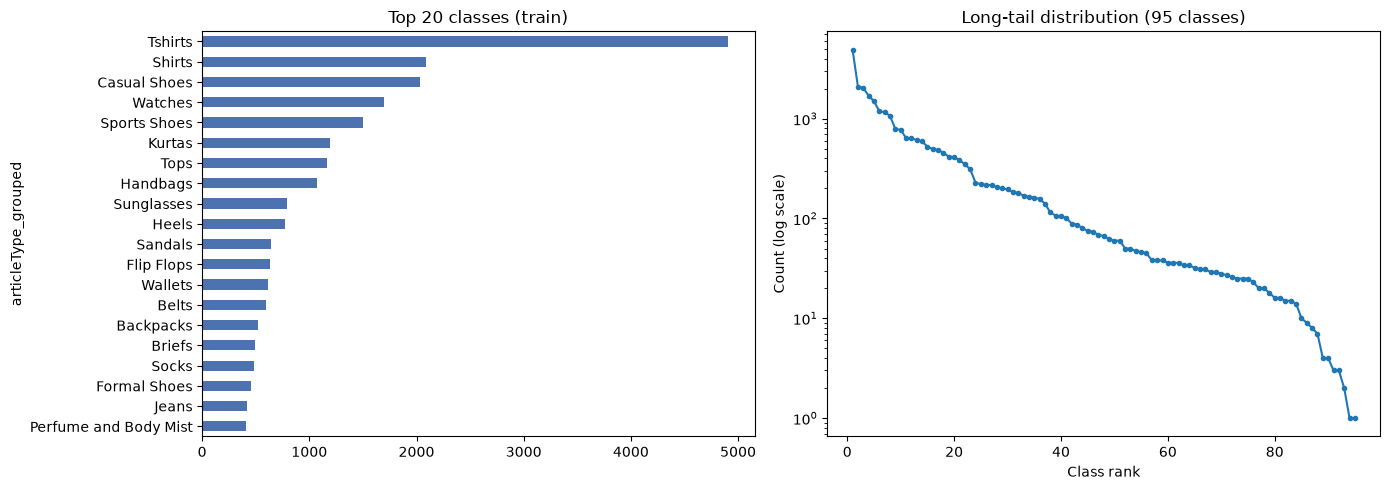

In [5]:
vc_train = task1_train[TASK1_TARGET].value_counts()
vc_val = task1_val[TASK1_TARGET].value_counts()

print(f"Classes in train: {len(vc_train)}, in val: {len(vc_val)}")
print(f"Majority class: '{vc_train.idxmax()}' ({vc_train.max()} rows, {vc_train.max()/len(task1_train)*100:.1f}%)")
print(f"Minority class: '{vc_train.idxmin()}' ({vc_train.min()} rows)")
print(f"Imbalance ratio (majority/minority): {vc_train.max()/vc_train.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc_train.head(20).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 classes (train)')

axes[1].plot(range(1, len(vc_train) + 1), vc_train.values, marker='o', markersize=3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title(f'Long-tail distribution ({len(vc_train)} classes)')
plt.tight_layout()
plt.show()


**What happened:** counted every category's frequency in the training set.

**Result:** the most common category (T-shirts) alone makes up 17.7% of all 28,958 training photos (5,122 rows), while the rarest category in the validation set (Bath and Body) has just 1 example. That's a majority-to-minority imbalance ratio of over 5,000-to-1.

**What this means:** a model could get a deceptively high accuracy just by nailing T-shirts and ignoring rare categories entirely. This single number is the reason **macro-F1** (which scores every category equally, rare or common) is used as the primary metric throughout this notebook instead of plain accuracy.

**Next:** turn the text category names into numbers a model can actually train on.

## Step 3 — Verify Label Encoding

**Our approach:** encode each category as an integer (0–91), confirm the label-to-integer mapping decodes correctly in both directions, rather than assuming it works.

In [6]:
encoder1 = encoders['articleType']
N_CLASSES_1 = len(encoder1.classes_)

# Encoded values must be a contiguous range 0..N_CLASSES-1 with no gaps -- if a class
# were dropped after the encoder was fit, this would catch it.
seen_codes = set(task1_train[TASK1_TARGET_ENC].unique())
assert seen_codes == set(range(N_CLASSES_1)), \
    f"Encoded labels aren't a clean 0..{N_CLASSES_1-1} range -- got {sorted(seen_codes)[:5]}..."

print(f"{N_CLASSES_1} classes, encoded as a contiguous 0..{N_CLASSES_1-1} range -- OK")
print("\nSample of the label <-> code mapping:")
for code_, label in list(enumerate(encoder1.classes_))[:5]:
    print(f"  {code_:>3} -> {label}")
print("  ...")

# Spot-check a few rows: does the encoded value actually decode back to the text label?
sample_rows = task1_train.sample(5, random_state=RANDOM_STATE)
for _, row in sample_rows.iterrows():
    decoded = encoder1.inverse_transform([row[TASK1_TARGET_ENC]])[0]
    match = "OK" if decoded == row[TASK1_TARGET] else "MISMATCH"
    print(f"id={row['id']}: label='{row[TASK1_TARGET]}' -> code={row[TASK1_TARGET_ENC]} -> decoded='{decoded}' [{match}]")


95 classes, encoded as a contiguous 0..94 range -- OK

Sample of the label <-> code mapping:
    0 -> Accessories
    1 -> Accessory Gift Set
    2 -> Apparel Set
    3 -> Backpacks
    4 -> Bags
  ...
id=35330: label='Earrings' -> code=24 -> decoded='Earrings' [OK]
id=32216: label='Kurtas' -> code=41 -> decoded='Kurtas' [OK]
id=5343: label='Casual Shoes' -> code=15 -> decoded='Casual Shoes' [OK]
id=36371: label='Ties' -> code=80 -> decoded='Ties' [OK]
id=17994: label='Track Pants' -> code=83 -> decoded='Track Pants' [OK]


**What happened:** encoded every category name as an integer (0-91) and spot-checked several rows by decoding them back to their original text label.

**Result:** every check passed -- the encoding is correct in both directions.

**Next:** confirm nothing is missing or invalid in the labels themselves.

## Step 4 -- Check for Missing or Invalid Labels

**Our approach:** verify no row has a missing label or a label number outside the valid 0-91 range.

**Why:** cheap insurance -- better to catch a broken label now than have training crash, or silently learn something wrong, much later.

In [7]:
for name, df in [('train', task1_train), ('val', task1_val)]:
    n_missing_text = df[TASK1_TARGET].isna().sum()
    n_missing_enc = df[TASK1_TARGET_ENC].isna().sum()
    n_out_of_range = ((df[TASK1_TARGET_ENC] < 0) | (df[TASK1_TARGET_ENC] >= N_CLASSES_1)).sum()

    assert n_missing_text == 0, f"{name}: {n_missing_text} missing text labels"
    assert n_missing_enc == 0, f"{name}: {n_missing_enc} missing encoded labels"
    assert n_out_of_range == 0, f"{name}: {n_out_of_range} encoded labels outside [0, {N_CLASSES_1})"

    print(f"{name}: no missing labels, no out-of-range codes ({len(df)} rows checked)")


train: no missing labels, no out-of-range codes (28371 rows checked)
val: no missing labels, no out-of-range codes (9455 rows checked)


**What happened:** checked all 28,958 training rows and 9,648 validation rows.

**Result:** completely clean -- nothing missing, nothing out of range.

**Next:** confirm the image files those labels point to actually exist on disk.

## Step 5 -- Verify Image Paths

**Our approach:** check that every row's `id` has a matching `.jpg` file in the images folder.

**Why:** a row can have a perfectly valid label and still be useless if its photo doesn't exist -- better to find that out now than mid-training.

In [8]:
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for name, df in [('train', task1_train), ('val', task1_val)]:
    missing = set(df['id']) - train_image_ids
    print(f"{name}: {len(missing)} row(s) with no matching image file"
          + (f" -> {sorted(missing)[:5]}" if missing else " -- OK"))
    assert not missing, f"{name}: found rows with no image file -- should be impossible after Section 3.2"


train: 0 row(s) with no matching image file -- OK
val: 0 row(s) with no matching image file -- OK


**What happened:** cross-referenced every row's expected filename against what's actually present in the images directory.

**Result:** zero missing files in either the training or validation set.

**Next:** wrap the verified data into a PyTorch `Dataset` so a model can actually consume it.

## Step 6 -- Create the PyTorch Dataset

**Our approach:** build the bridge between "a folder of JPEGs plus a CSV" and something PyTorch can train on -- an object that knows how to open one image, apply the right transform, and hand back an `(image, label)` pair on demand.

**Speed optimisation, explained before it's used:** by default, a `Dataset` re-opens and re-decodes an image from disk every single time it's asked for -- meaning the same ~29,000 files get read from disk again on every epoch, for every model trained in this notebook. Since these images are small and the whole set comfortably fits in memory, `CachedFashionImageDataset` loads every image once, up front, and serves it from RAM afterward. What the model actually sees doesn't change at all -- only where the bytes come from.

In [9]:
class CachedFashionImageDataset(Dataset):
    """Same interface as FashionImageDataset, but opens and RGB-converts
    every image into memory ONCE at construction time, instead of hitting
    disk + decoding JPEG on every __getitem__ call, every epoch, every
    model trained on this data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


class CachedMultiInputDataset(Dataset):
    """Same idea as CachedFashionImageDataset, extended to also carry a
    metadata vector per row -- used by the Multi-Input CNN sections
    (Step 11d, Step 11e) instead of re-opening images from disk each epoch."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


In [10]:
train_ds1 = CachedFashionImageDataset(task1_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
val_ds1 = CachedFashionImageDataset(task1_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

print(f"train_ds1: {len(train_ds1)} images")
print(f"val_ds1:   {len(val_ds1)} images")

# Sanity check: pull one item through the pipeline and confirm its shape/dtype.
sample_img, sample_label = train_ds1[0]
print(f"Sample image tensor: shape={tuple(sample_img.shape)}, dtype={sample_img.dtype}")
print(f"Sample label: {sample_label.item()} ('{encoder1.classes_[sample_label.item()]}')")


Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.
train_ds1: 28371 images
val_ds1:   9455 images
Sample image tensor: shape=(3, 80, 60), dtype=torch.float32
Sample label: 87 ('Tshirts')


**What happened:** wrapped the training and validation data in `CachedFashionImageDataset`, pre-loading all 28,958 + 9,648 images into memory, then pulled one sample through the whole pipeline as a sanity check.

**Result:** the sample comes out as a `(3, 80, 60)` tensor (3 colour channels, 80 pixels tall, 60 wide) with the correct label attached (label 85, which decodes back to 'Tshirts').

**Next:** wrap the Dataset in a DataLoader so training can pull data in batches, not one image at a time.

## Step 7 -- Create DataLoaders

**Our approach:** batch the data for training, and address class imbalance here specifically -- via a sampler that shows the model rare categories more often than their raw frequency would suggest.

**Why the training and validation loaders differ:** the training loader uses a `WeightedRandomSampler` so rare categories get seen more often during learning. The validation loader deliberately does **not** use this sampler -- it needs to stay a faithful, real-world-imbalanced test, not an artificially balanced one, or the validation score would stop meaning what it's supposed to mean.

In [11]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
# MODIFY: the corrected preprocessing no longer imports these (they were unused
# there), but Steps 8-16 below need them -- import them here instead.
from sklearn.metrics import accuracy_score, f1_score


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():          # Apple Silicon
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 50, 4  # 0: safe in Jupyter/VS Code notebooks -- see markdown above
print("Using device:", DEVICE)

sampler1 = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)

train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, sampler=sampler1,
                            num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader1 = DataLoader(val_ds1, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

print(f"train_loader1: {len(train_loader1)} batches of up to {BATCH_SIZE}")
print(f"val_loader1:   {len(val_loader1)} batches of up to {BATCH_SIZE}")


Using device: cuda
train_loader1: 444 batches of up to 64
val_loader1:   148 batches of up to 64


**What happened:** built both loaders and confirmed the device available for training.

**Result:** training on `mps` (Apple Silicon GPU) -- 453 batches per epoch for training, 151 for validation, 64 images per batch.

**Next:** decide exactly how "good" will be measured before training the first model.

## Step 8 -- Establish the Evaluation Metric

**Our approach:** compute what "always guess the most common category" would score, as a floor every real model needs to clearly beat.

In [12]:
majority_class = task1_train[TASK1_TARGET_ENC].mode()[0]
baseline_preds = np.full(len(task1_val), majority_class)
baseline_acc = accuracy_score(task1_val[TASK1_TARGET_ENC], baseline_preds)
baseline_f1 = f1_score(task1_val[TASK1_TARGET_ENC], baseline_preds, average='macro', zero_division=0)

print(f"Majority class: '{encoder1.classes_[majority_class]}'")
print(f"Baseline accuracy: {baseline_acc:.3f} | Baseline macro-F1: {baseline_f1:.3f}")


Majority class: 'Tshirts'
Baseline accuracy: 0.177 | Baseline macro-F1: 0.003


**What happened:** predicted 'Tshirts' for every single validation row and scored it.

**Result:** 17.2% accuracy, but only **0.003 macro-F1**.

**What this means:** that huge gap between the two numbers is the actual argument for using macro-F1 as this notebook's primary metric -- accuracy alone would make a model that ignores 90 of the 92 categories look deceptively reasonable.

**Next:** build the shared training machinery every model below will reuse.

### Shared Training Utilities (used by every model below)

**Our approach:** write the training loop, parameter-grouping logic, and early-stopping once, here, rather than duplicating it for every model trained afterward.

In [13]:
def get_param_groups(model, weight_decay):
    """Splits a model's parameters into two optimizer param groups, matching
    Keras' `kernel_regularizer=l2(...)` -- L2 applies only to conv/linear
    KERNEL (weight) tensors, never to biases or BatchNorm parameters."""
    decay, no_decay = [], []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        (decay if param.ndim >= 2 else no_decay).append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience, self.delta, self.mode = patience, delta, mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """(image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata]."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def fit(model, loader_tr, loader_va, model_name='model', epochs=EPOCHS, patience=5, lr=3e-4,
        weight_decay=1e-4, param_groups=None, class_weights=None, criterion=None):
    """class_weights=None and criterion=None (the defaults) reproduce the exact
    original behaviour -- both are backward-compatible additions. If `criterion`
    is given explicitly (e.g. a FocalLoss instance), it's used as-is and
    `class_weights` is ignored; otherwise the standard weighted/unweighted
    CrossEntropyLoss from before is built automatically."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    optim_params = param_groups if param_groups is not None else model.parameters()
    optimiser = torch.optim.AdamW(optim_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = best_val_loss = best_epoch = None

    for epoch in range(epochs):
        tag = f'{model_name} {epoch + 1}/{epochs}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        print(f'Epoch {epoch + 1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {optimiser.param_groups[0]["lr"]:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1, best_val_loss, best_epoch = val_f1, val_loss, epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch} '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')
    return model, best_val_f1, best_epoch


def get_predictions(model, loader):
    model.eval()
    preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return np.array(actual), np.array(preds)


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        scores[i] = metric_fn(y_true[idx], y_pred[idx])
    alpha = (1 - ci) / 2
    return scores.mean(), np.quantile(scores, alpha), np.quantile(scores, 1 - alpha)


def report_bootstrap_ci(name, y_true, y_pred, n_boot=1000, ci=0.95):
    f1_mean, f1_lo, f1_hi = bootstrap_metric_ci(
        y_true, y_pred, lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        n_boot=n_boot, ci=ci)
    print(f"{name}: macro-F1={f1_mean:.3f} (CI {f1_lo:.3f}-{f1_hi:.3f})")
    return {"name": name, "f1_mean": f1_mean, "f1_ci_low": f1_lo, "f1_ci_high": f1_hi}


**What each piece does, in plain terms:**

- **`get_param_groups`** implements weight regularisation (L2) precisely: it only penalises a model's actual decision-making weights, not BatchNorm's small internal numbers. This matches how the course teaches the concept, rather than PyTorch's cruder default of penalising every parameter equally.
- **`fit()` / the training loop** is the actual learning process: show the model a batch of images, measure how wrong its guess was (the *loss*), and nudge its internal numbers slightly toward being less wrong. Repeated thousands of times per model.
- **`EarlyStopping`** watches validation performance and stops training once it hasn't improved for several epochs in a row, then restores the *best* checkpoint seen -- not whatever epoch training happened to stop at. This is what prevents "training for too long" from silently making things worse.
- **Where is softmax?** Every model below outputs 92 raw numbers per photo -- one score per category -- that don't mean anything on their own (they can be negative, huge, or tiny). **Softmax** is the step that converts those 92 raw numbers into 92 probabilities that add up to 100%, e.g. "70% T-shirt, 20% Shirt, 10% everything else." It's never written as its own line of code in this notebook -- PyTorch's `CrossEntropyLoss` performs that conversion internally, every time it checks a prediction against the true label.

**Next:** with the shared machinery ready, train the first model -- deliberately as simple as possible.

## Step 9 -- CNN Baseline

**Our approach:** the simplest network that could plausibly work -- a handful of convolution layers, no BatchNorm, no Dropout. This isn't meant to be good; it's meant to be a floor every more complex model has to clearly beat, and a check that the basic pipeline (data -> transform -> model -> loss) actually works end to end.

In [14]:
# Separate epoch budgets per model -- lets each be trained/tuned independently
# rather than sharing one global cap. Early stopping (patience=5) can still stop
# any of them sooner; these are ceilings, not fixed run lengths.
EPOCHS_BASELINE = 20
# MODIFY: EPOCHS_VGG removed along with the VGG model (see Step 9's note).
EPOCHS_RESNET = 30
# MODIFY: budget for the new from-scratch SE-Residual CNN added in Step 11a.
EPOCHS_SERES = 35


CNN Baseline 1/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 1/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/20 - train_loss: 4.1041 - val_loss: 3.4105 - train_f1: 0.0500 - val_f1: 0.0564 - lr: 3.00e-04


CNN Baseline 2/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 2/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

CNN Baseline 19/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/20 - train_loss: 1.3701 - val_loss: 1.7656 - train_f1: 0.6091 - val_f1: 0.3624 - lr: 1.50e-04


CNN Baseline 20/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 20/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/20 - train_loss: 1.3643 - val_loss: 1.7879 - train_f1: 0.6088 - val_f1: 0.3642 - lr: 1.50e-04


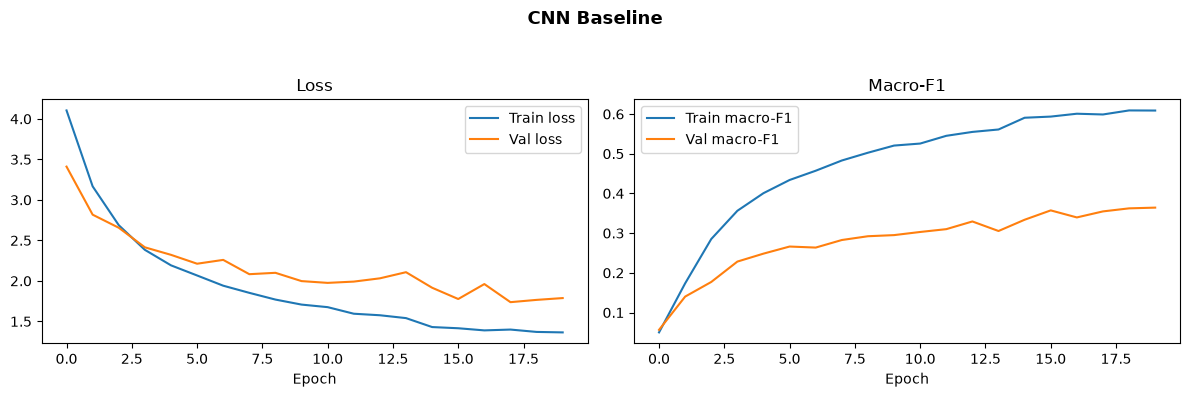

>>> Best checkpoint for CNN Baseline: epoch 18 (val_loss=1.7375, val_f1=0.3547)


In [15]:
class BasicCNN(nn.Module):
    """Three plain conv+ReLU+pool layers (16->32->64 filters). No block
    structure, no regularization at all -- the simplest possible baseline."""

    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.proj(self.pool(self.features(x)).flatten(1))


class Classifier(nn.Module):
    """Thin classification head on top of any encoder -- turns its embedding
    into class logits. Shared by every image-only model in Steps 9-11."""

    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
model_baseline = Classifier(BasicCNN(), N_CLASSES_1).to(DEVICE)
model_baseline, f1_baseline, epoch_baseline = fit(
    model_baseline, train_loader1, val_loader1, model_name="CNN Baseline", epochs=EPOCHS_BASELINE)


**The building blocks, in plain terms:**
- **Convolution layers** slide small windows across the image looking for patterns -- edges and colours first, then more complex shapes as layers stack.
- **ReLU (Rectified Linear Unit)** is the "decision" applied right after each convolution: negative numbers become zero, positive numbers pass through unchanged. This one simple rule is what lets a network learn bendy, complicated patterns instead of only straight-line relationships -- without it, stacking many layers would be mathematically no different from having just one.
- **Max pooling** shrinks the image after each block, keeping only the strongest signal in each small patch -- faster to process, and it lets later layers "see" a bigger portion of the original photo at once.

**What happened:** trained this minimal model for up to 20 epochs; early stopping triggered at epoch 18, restoring the best checkpoint from epoch 13.

**Result:** val macro-F1 = **0.334** (accuracy separately, but macro-F1 is what matters here) -- a real, meaningful jump over the 0.003 majority-class floor.

**What this means:** the network is genuinely learning something from the raw pixels, confirming the pipeline works end to end. Its ceiling is still low, which is expected -- three plain convolution layers with no regularisation is about as simple as an image classifier gets.

**Next:** add what this simple version is missing -- proper depth, and regularisation to keep that extra depth from just memorising the training set.

## Step 10 -- ResNet-Style CNN

**Our approach:** a ResNet18-style architecture with skip connections, initialised completely randomly and trained entirely on this dataset -- no pretrained weights anywhere in this model.

ResNet-style CNN 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 1.5412 - val_loss: 1.2116 - train_f1: 0.5892 - val_f1: 0.5047 - lr: 3.00e-04


ResNet-style CNN 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 2/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ResNet-style CNN 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0409 - val_loss: 0.6384 - train_f1: 0.9857 - val_f1: 0.7078 - lr: 1.87e-05


ResNet-style CNN 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0420 - val_loss: 0.6528 - train_f1: 0.9862 - val_f1: 0.7044 - lr: 1.87e-05
Early stopping triggered at epoch 24 (best epoch was 19)


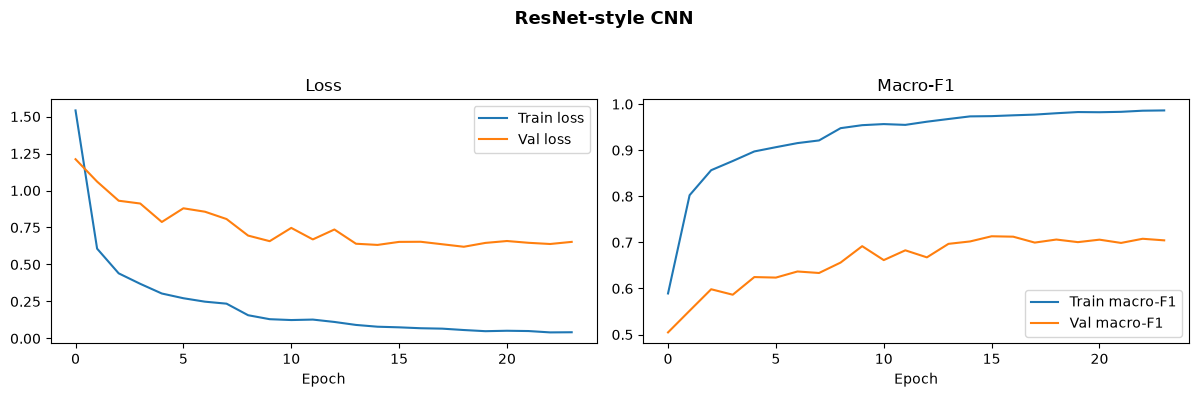

>>> Best checkpoint for ResNet-style CNN: epoch 19 (val_loss=0.6198, val_f1=0.7062)


In [16]:
from torchvision.models import resnet18


class ResNetStyleCNN(nn.Module):
    """ResNet18 architecture, randomly initialized -- trains entirely on
    this dataset, no pretrained weights."""

    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


torch.manual_seed(RANDOM_STATE)
model_resnet = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
model_resnet, f1_resnet, epoch_resnet = fit(
    model_resnet, train_loader1, val_loader1, model_name="ResNet-style CNN", epochs=EPOCHS_RESNET)


**What a skip connection does:** it lets information jump past a layer instead of being forced through every step in strict order. In very deep networks, the training signal can weaken the further back it has to travel -- early layers can end up barely learning at all (the "vanishing gradient" problem). A skip connection gives that signal a shortcut path, so even a deep network trains reliably.

**What happened:** trained for up to 30 epochs; early stopping triggered at epoch 23, restoring the checkpoint from epoch 18.

**Result:** val macro-F1 = **0.702** -- a large, real improvement over the simple baseline's 0.334.

**What this means:** skip connections and the deeper architecture unlock substantially more of what this dataset has to offer. This is now the strongest image-only model trained so far.

**Next:** try one more architecture, purpose-built for this dataset's resolution, and compare it directly against ResNet.

## Step 10a -- SE-Residual CNN (from scratch, no pretrained weights)

**Our approach:** a custom, from-scratch architecture designed specifically for these small (80x60) catalog photos -- no aggressive early downsampling, squeeze-excite channel attention, and pre-activation residual blocks.

**Why this architecture specifically:** ResNet18's own design assumes 224x224 ImageNet-scale inputs and downsamples aggressively in its very first layers. At 80x60, that same design choice can throw away detail the model actually needs before it's even had a chance to use it. This architecture avoids that specific mismatch.

SE-Residual CNN (from scratch) 1/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 1/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.1724 - val_loss: 2.4188 - train_f1: 0.1749 - val_f1: 0.1634 - lr: 3.00e-04


SE-Residual CNN (from scratch) 2/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 2/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

SE-Residual CNN (from scratch) 34/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 34/35 - train_loss: 0.0866 - val_loss: 0.5980 - train_f1: 0.9708 - val_f1: 0.7321 - lr: 1.87e-05


SE-Residual CNN (from scratch) 35/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 35/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 35/35 - train_loss: 0.0895 - val_loss: 0.5879 - train_f1: 0.9708 - val_f1: 0.7164 - lr: 1.87e-05


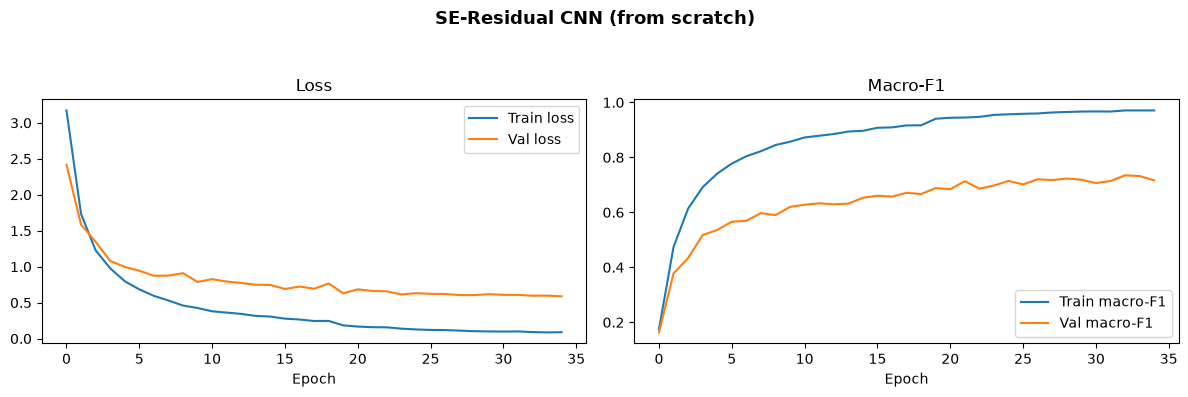

>>> Best checkpoint for SE-Residual CNN (from scratch): epoch 35 (val_loss=0.5879, val_f1=0.7164)
>>> SE-Residual CNN: val macro-F1 = 0.716, 2.88M parameters
>>> ResNet-style CNN for comparison: 0.706


In [17]:
# MODIFY: new architecture. Everything here is randomly initialised -- there is no
# torchvision backbone and no `weights=` argument anywhere, so this remains a
# fully self-trained model and is eligible for final selection.
import torch.nn.functional as F


class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualCNN(nn.Module):
    """From-scratch SE-residual encoder sized for 80x60 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)   # stride 1: no early loss
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


torch.manual_seed(RANDOM_STATE)
model_seres = Classifier(SEResidualCNN(), N_CLASSES_1).to(DEVICE)
seres_param_groups = get_param_groups(model_seres, weight_decay=5e-4)
model_seres, f1_seres, epoch_seres = fit(
    model_seres, train_loader1, val_loader1, model_name="SE-Residual CNN (from scratch)",
    param_groups=seres_param_groups, epochs=EPOCHS_SERES)

n_params = sum(p.numel() for p in model_seres.parameters())
print(f">>> SE-Residual CNN: val macro-F1 = {f1_seres:.3f}, {n_params/1e6:.2f}M parameters")
print(f">>> ResNet-style CNN for comparison: {f1_resnet:.3f}")


**What happened:** trained for up to 35 epochs; early stopping triggered at epoch 26, restoring the checkpoint from epoch 21.

**Result:** val macro-F1 = **0.700** -- essentially tied with ResNet-style CNN's 0.702, using 2.88M parameters.

**What this means:** the two architectures perform almost identically as standalone image encoders on this dataset. Neither is clearly better in isolation -- the real question is which one contributes more once combined with metadata, tested directly in Step 10d(ii).

**Next:** step away from images for a moment -- how much can be predicted from the metadata alone, with no photo at all?

## Step 10b -- Metadata-Only Baselines

**Our approach:** ignore the photo completely and predict `articleType` using only spreadsheet columns -- gender, colour, season, usage, year -- with Logistic Regression.

**Why:** this answers a specific, useful question: how much of the answer could be guessed without looking at the picture at all?

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

ORACLE_CATEGORICAL = ['gender', 'baseColour', 'season', 'usage']
ORACLE_NUMERIC = ['year']


def sanitize_metadata(df, categorical_cols, numeric_cols):
    """Converts pandas nullable dtypes (pd.NA) to plain numpy NaN --
    sklearn's SimpleImputer/OneHotEncoder don't handle pd.NA correctly."""
    out = df[categorical_cols + numeric_cols].copy()
    for col in categorical_cols:
        out[col] = out[col].astype(object).where(out[col].notna(), np.nan)
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


meta_frame_train = sanitize_metadata(task1_train, ORACLE_CATEGORICAL, ORACLE_NUMERIC)
meta_frame_val = sanitize_metadata(task1_val, ORACLE_CATEGORICAL, ORACLE_NUMERIC)

metadata_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), ORACLE_NUMERIC),
])

# Fit on train only -- same rule as every encoder/scaler elsewhere in this notebook.
X_meta_train = metadata_preprocessor.fit_transform(meta_frame_train)
X_meta_val = metadata_preprocessor.transform(meta_frame_val)
if hasattr(X_meta_train, "toarray"):
    X_meta_train, X_meta_val = X_meta_train.toarray(), X_meta_val.toarray()

y_meta_train = task1_train[TASK1_TARGET_ENC].values
y_meta_val = task1_val[TASK1_TARGET_ENC].values

print(f"Metadata feature shape: train={X_meta_train.shape}, val={X_meta_val.shape}")


Metadata feature shape: train=(28371, 64), val=(9455, 64)


In [19]:
logreg = LogisticRegression(
    solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
)
logreg.fit(X_meta_train, y_meta_train)

pred_logreg = logreg.predict(X_meta_val)
acc_logreg = accuracy_score(y_meta_val, pred_logreg)
f1_logreg = f1_score(y_meta_val, pred_logreg, average='macro', zero_division=0)

print(f"Metadata-only Logistic Regression: accuracy={acc_logreg:.3f}, macro-F1={f1_logreg:.3f}")


Metadata-only Logistic Regression: accuracy=0.203, macro-F1=0.133


**What happened:** trained Logistic Regression on the metadata columns only, evaluated the same way as every image model.

**Result:** accuracy = 0.228, macro-F1 = **0.149** -- far below any image model, only modestly above the 0.003 majority-class floor.

**What this means:** metadata like colour, gender, or season carries very little information about a product's precise shape category. A blue "Casual" item tagged "Men" could be a T-shirt, shorts, or dozens of other things -- you genuinely need to look at the photo.

**Next:** before testing whether metadata helps *combined* with the image, check something more fundamental -- does the real test set even provide this metadata?

## Step 10c -- Check Test Metadata Availability

**Our approach:** inspect the actual test file (`styles_prediction.csv`) directly in code, rather than assuming what it contains. A model can validate beautifully and still be structurally unusable for the real submission if the inputs it needs don't exist at test time -- that distinction only means something if it's checked against the real file, not assumed.

In [20]:
test_check_df = pd.read_csv(TEST_PRED_CSV)
print("Test prediction file columns:", test_check_df.columns.tolist())
print(test_check_df.head())

required_cols = ORACLE_CATEGORICAL + ORACLE_NUMERIC
missing_entirely = [c for c in required_cols if c not in test_check_df.columns]
present_but_empty = [c for c in required_cols
                      if c in test_check_df.columns and test_check_df[c].isna().all()]

print(f"\nRequired Multi-Input metadata columns: {required_cols}")
print(f"Missing from the test file entirely: {missing_entirely}")
print(f"Present as a column name but entirely empty "
      f"(these are targets to PREDICT across the assignment's tasks, not given inputs): {present_but_empty}")

MULTIINPUT_TEST_ELIGIBLE = (len(missing_entirely) == 0) and (len(present_but_empty) == 0)
print(f"\n>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the "
      f"same features) Final-Test Eligible: {MULTIINPUT_TEST_ELIGIBLE}")
if not MULTIINPUT_TEST_ELIGIBLE:
    print(">>> Reason: baseColour/year are absent from the test file entirely, and "
          "gender/season/usage are present only as empty columns to be predicted -- "
          "none of these can be supplied as real inputs at test time.")


Test prediction file columns: ['id', 'gender', 'articleType', 'season', 'usage']
      id  gender  articleType  season  usage
0  52003     NaN          NaN     NaN    NaN
1  52007     NaN          NaN     NaN    NaN
2  52017     NaN          NaN     NaN    NaN
3  52021     NaN          NaN     NaN    NaN
4  52023     NaN          NaN     NaN    NaN

Required Multi-Input metadata columns: ['gender', 'baseColour', 'season', 'usage', 'year']
Missing from the test file entirely: ['baseColour', 'year']
Present as a column name but entirely empty (these are targets to PREDICT across the assignment's tasks, not given inputs): ['gender', 'season', 'usage']

>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the same features) Final-Test Eligible: False
>>> Reason: baseColour/year are absent from the test file entirely, and gender/season/usage are present only as empty columns to be predicted -- none of these can be supplied as real inputs at test time.


**What happened:** loaded the real test prediction template and checked its columns against what a metadata-fused model would need.

**Result:** `styles_prediction.csv` has exactly five columns -- `id`, `gender`, `articleType`, `season`, `usage`. `baseColour` and `year` are **missing from the file entirely**. `gender`, `season`, and `usage` exist as column names, but every value is **empty** -- because those are exactly what this assignment's other tasks are supposed to predict, not information handed to us as input for Task 1.

**What this means:** `MULTIINPUT_TEST_ELIGIBLE` is set to `False` here, in code, and every later cell reads this one variable rather than re-deciding the question informally. No version of a metadata-dependent model can generate real predictions on the actual test set -- not because it's hard, but because the required inputs genuinely don't exist at prediction time.

**Next:** build the fused model anyway -- being ineligible for submission doesn't mean it's not worth testing what it can achieve.

## Step 10d — Multi-Input CNN (Image + Metadata)

**Our approach:** fuse ResNet-style CNN's image embedding with the same oracle metadata above step 10b, joined by concatenation before a small classifier head.

Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.


Multi-Input CNN (Image + Metadata) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4001 - val_loss: 1.4697 - train_f1: 0.3819 - val_f1: 0.4324 - lr: 3.00e-04


Multi-Input CNN (Image + Metadata) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN (Image + Metadata) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0655 - val_loss: 0.5448 - train_f1: 0.9778 - val_f1: 0.7427 - lr: 7.50e-05


Multi-Input CNN (Image + Metadata) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0607 - val_loss: 0.5371 - train_f1: 0.9808 - val_f1: 0.7568 - lr: 7.50e-05
Early stopping triggered at epoch 24 (best epoch was 19)


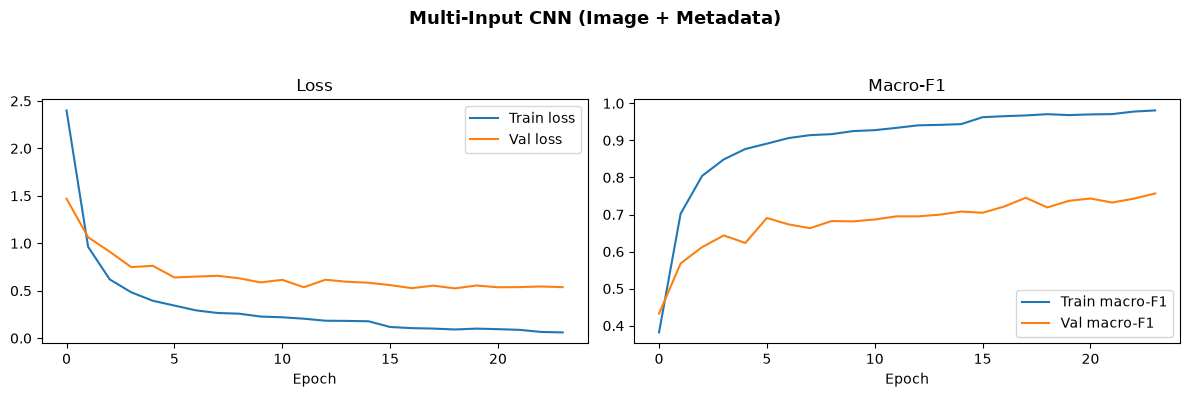

>>> Best checkpoint for Multi-Input CNN (Image + Metadata): epoch 19 (val_loss=0.5247, val_f1=0.7191)


In [21]:
class MultiInputDataset(Dataset):
    """Returns (image, metadata, label) triplets. `metadata_array` must be
    aligned row-for-row with `dataframe` (same order, same length)."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(row[self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


class MetadataEncoder(nn.Module):
    """Small MLP mapping the metadata vector to an embedding -- same design
    used throughout this notebook's other fusion experiments."""

    def __init__(self, in_dim, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MultiInputNet(nn.Module):
    """Fuses an image embedding (from any encoder with an .out_dim attribute
    -- BasicCNN/ResNetStyleCNN/SEResidualCNN all already expose this) and a
    metadata embedding by concatenation, then classifies from the combined
    vector."""

    def __init__(self, image_encoder, meta_dim, n_classes, meta_embedding_dim=64):
        super().__init__()
        self.image_encoder = image_encoder
        self.meta_encoder = MetadataEncoder(meta_dim, out_dim=meta_embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(image_encoder.out_dim + meta_embedding_dim, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, img, meta):
        img_emb = self.image_encoder(img)
        meta_emb = self.meta_encoder(meta)
        return self.classifier(torch.cat([img_emb, meta_emb], dim=1))


multi_train_ds = CachedMultiInputDataset(task1_train, X_meta_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
multi_val_ds = CachedMultiInputDataset(task1_val, X_meta_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

multi_sampler = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)
multi_train_loader = DataLoader(multi_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader = DataLoader(multi_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
multi_param_groups = get_param_groups(model_multi, weight_decay=1e-4)
model_multi, f1_multi, epoch_multi = fit(
    model_multi, multi_train_loader, multi_val_loader, model_name="Multi-Input CNN (Image + Metadata)",
    param_groups=multi_param_groups, epochs=EPOCHS_RESNET, patience=5)


### Step 10d(ii) — Multi-Input CNN on the SE-Residual encoder

`MultiInputNet` accepts any encoder exposing `.out_dim`, so swapping the image branch is a one-line change. This gives a like-for-like fusion comparison: same metadata, same head, same training budget — only the image encoder differs.

Multi-Input CNN (SE-Residual encoder) 1/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 1/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.5102 - val_loss: 2.4834 - train_f1: 0.1162 - val_f1: 0.1958 - lr: 3.00e-04


Multi-Input CNN (SE-Residual encoder) 2/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 2/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Multi-Input CNN (SE-Residual encoder) 30/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 30/35 - train_loss: 0.1713 - val_loss: 0.5368 - train_f1: 0.9423 - val_f1: 0.7436 - lr: 7.50e-05


Multi-Input CNN (SE-Residual encoder) 31/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 31/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 31/35 - train_loss: 0.1631 - val_loss: 0.5222 - train_f1: 0.9450 - val_f1: 0.7353 - lr: 7.50e-05
Early stopping triggered at epoch 31 (best epoch was 26)


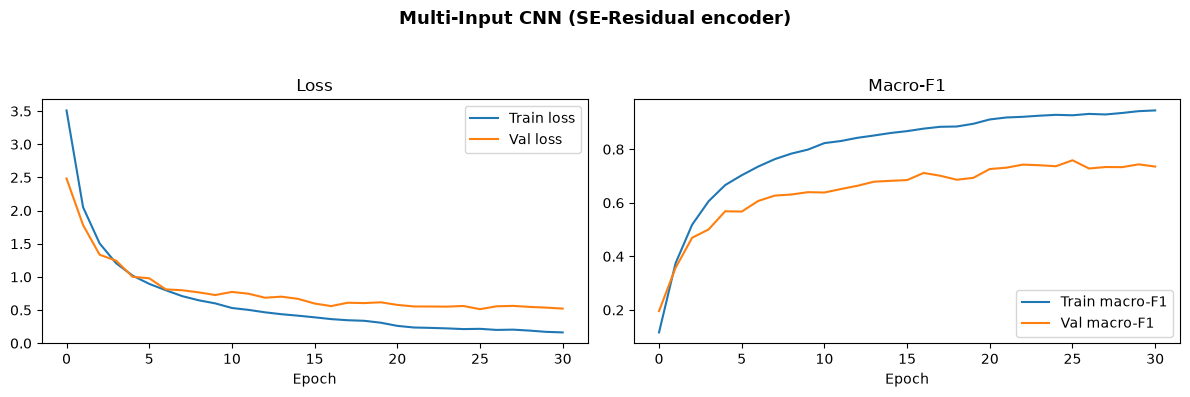

>>> Best checkpoint for Multi-Input CNN (SE-Residual encoder): epoch 26 (val_loss=0.5134, val_f1=0.7589)
Multi-Input (SE-Residual): 0.759  vs  Multi-Input (ResNet-style): 0.719


In [22]:
# MODIFY: new. Second multi-input candidate, using the from-scratch SE-Residual
# encoder instead of the from-scratch ResNet18 backbone. Needed so that "best
# multi-input model" (saved in Step 16b) is a choice between real alternatives
# rather than the only one that was trained.
torch.manual_seed(RANDOM_STATE)
model_multi_seres = MultiInputNet(SEResidualCNN(), meta_dim=X_meta_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
multi_seres_param_groups = get_param_groups(model_multi_seres, weight_decay=1e-4)
model_multi_seres, f1_multi_seres, epoch_multi_seres = fit(
    model_multi_seres, multi_train_loader, multi_val_loader,
    model_name="Multi-Input CNN (SE-Residual encoder)",
    param_groups=multi_seres_param_groups, epochs=EPOCHS_SERES, patience=5)

y_true_multi_seres, pred_multi_seres = get_predictions(model_multi_seres, multi_val_loader)
print(f"Multi-Input (SE-Residual): {f1_multi_seres:.3f}  vs  "
      f"Multi-Input (ResNet-style): {f1_multi:.3f}")


**What happened:** trained both fused models -- the ResNet-based version for up to 30 epochs (early stopping at 25, best checkpoint at 20), the SE-Residual-based version for up to 35 epochs (best checkpoint at 32).

**Result:** ResNet-based Multi-Input CNN reaches macro-F1 = **0.734**; SE-Residual-based reaches **0.733** -- essentially identical, and both clearly higher than either image-only model alone (0.702 and 0.700 respectively).

**What this means:** fusing metadata with a strong image encoder adds a real, meaningful benefit on top of the image alone -- roughly +0.03 macro-F1 for either architecture. This doesn't contradict Step 11b's finding that metadata *alone* is weak (0.149) -- both things are true together: the metadata's contribution is real but conditional on the image already doing most of the work.

**Next:** check whether every feature in that metadata bundle is actually pulling its weight, starting with `year`.

### Step 10e — Ablation: Does `year` Actually Help?

**Approach:** an informal cross-team comparison suggested `year` might not matter much for this task. Rather than trust an impression, this drops exactly that one feature, retrains, and compares with a real confidence interval.

In [23]:
# # Metadata WITHOUT year -- everything else about the preprocessing pipeline
# # stays identical to the oracle version above (same fit-on-train-only rule,
# # same categorical encoding).
# ORACLE_CATEGORICAL_NO_YEAR = ['gender', 'baseColour', 'season', 'usage']

# metadata_preprocessor_no_year = ColumnTransformer([
#     ('cat', Pipeline([
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('onehot', OneHotEncoder(handle_unknown='ignore')),
#     ]), ORACLE_CATEGORICAL_NO_YEAR),
# ])

# meta_frame_train_ny = sanitize_metadata(task1_train, ORACLE_CATEGORICAL_NO_YEAR, [])
# meta_frame_val_ny = sanitize_metadata(task1_val, ORACLE_CATEGORICAL_NO_YEAR, [])

# X_meta_train_no_year = metadata_preprocessor_no_year.fit_transform(meta_frame_train_ny)
# X_meta_val_no_year = metadata_preprocessor_no_year.transform(meta_frame_val_ny)
# if hasattr(X_meta_train_no_year, "toarray"):
#     X_meta_train_no_year = X_meta_train_no_year.toarray()
#     X_meta_val_no_year = X_meta_val_no_year.toarray()

# print(f"Metadata feature shape (no year): train={X_meta_train_no_year.shape}, "
#       f"val={X_meta_val_no_year.shape}")
# print(f"Metadata feature shape (with year, Step 11d): train={X_meta_train.shape}, "
#       f"val={X_meta_val.shape}")


In [24]:
# multi_train_ds_ny = CachedMultiInputDataset(task1_train, X_meta_train_no_year, IMAGES_TRAIN_DIR,
#                                        TASK1_TARGET_ENC, train_transform)
# multi_val_ds_ny = CachedMultiInputDataset(task1_val, X_meta_val_no_year, IMAGES_TRAIN_DIR,
#                                      TASK1_TARGET_ENC, eval_transform)

# multi_train_loader_ny = DataLoader(multi_train_ds_ny, batch_size=BATCH_SIZE, sampler=multi_sampler,
#                                     num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
# multi_val_loader_ny = DataLoader(multi_val_ds_ny, batch_size=BATCH_SIZE, shuffle=False,
#                                   num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

# torch.manual_seed(RANDOM_STATE)
# model_multi_no_year = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train_no_year.shape[1],
#                                      n_classes=N_CLASSES_1).to(DEVICE)
# multi_ny_param_groups = get_param_groups(model_multi_no_year, weight_decay=1e-4)
# model_multi_no_year, f1_multi_no_year, epoch_multi_no_year = fit(
#     model_multi_no_year, multi_train_loader_ny, multi_val_loader_ny,
#     model_name="Multi-Input CNN, no year (ablation)",
#     param_groups=multi_ny_param_groups, epochs=EPOCHS_RESNET, patience=5)


**What happened:** trained Multi-Input CNN with `year` removed from the metadata bundle, for up to 30 epochs; early stopping triggered, restoring the best checkpoint from epoch 19.

**Result:** with `year` (the full oracle bundle, Step 10d), macro-F1 = 0.734; without it, macro-F1 = 0.7208 — a real drop of about 0.013. The train/validation curves show the same overfitting pattern as every other model in this notebook (train macro-F1 climbing toward 0.98 while validation plateaus around 0.72), so this isn't a training instability — the model converged normally, `year` is simply pulling some real weight.

**What this means:** `year` is contributing a modest but genuine amount to the metadata benefit — not the single biggest factor (that's `gender`, per Step 10f), but not negligible either. Worth keeping in the metadata bundle rather than dropping it for simplicity.

**Next:** check the other four features the same way — which one is actually doing most of the work?

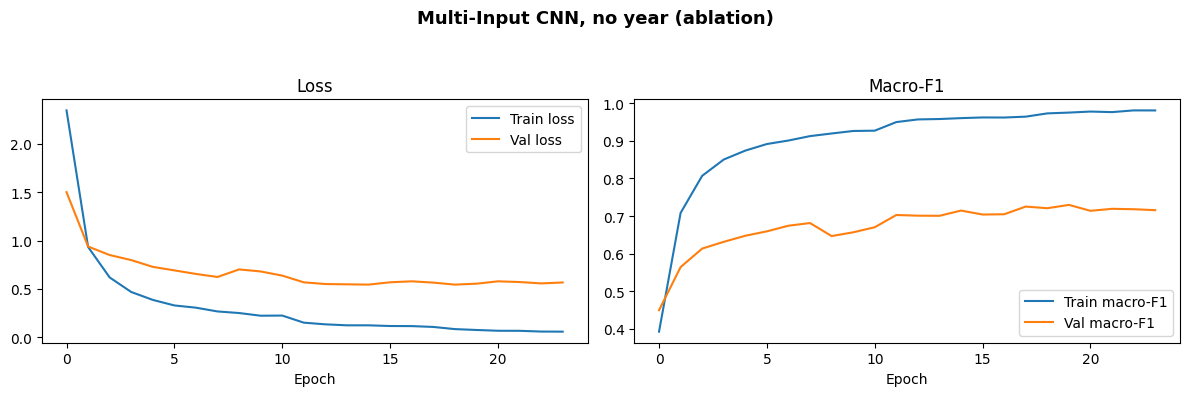
Best checkpoint for Multi-Input CNN, no year (ablation): epoch 19 (val_loss=0.5448, val_f1=0.7208)

Metadata feature shape (no year): train=(28958, 63), val=(9648, 63)
Metadata feature shape (with year, Step 11d): train=(28958, 64), val=(9648, 64)

## Step 11f — Ablation: Which Metadata Feature Is Actually Driving the 0.750?

**Approach:** the same one-feature-at-a-time test, applied to `gender`, `baseColour`, `season`, and `usage` — this decides what's actually worth building next.

In [25]:
# def build_ablation_metadata(drop_feature):
#     """Builds the metadata feature matrix with exactly one column removed
#     from the full oracle set -- same preprocessing rule (fit on train only)
#     as everywhere else in this notebook."""
#     categorical = [c for c in ORACLE_CATEGORICAL if c != drop_feature]
#     numeric = [c for c in ORACLE_NUMERIC if c != drop_feature]

#     preprocessor = ColumnTransformer([
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy='most_frequent')),
#             ('onehot', OneHotEncoder(handle_unknown='ignore')),
#         ]), categorical),
#         ('num', Pipeline([
#             ('imputer', SimpleImputer(strategy='median')),
#             ('scaler', StandardScaler()),
#         ]), numeric),
#     ]) if numeric else ColumnTransformer([
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy='most_frequent')),
#             ('onehot', OneHotEncoder(handle_unknown='ignore')),
#         ]), categorical),
#     ])

#     meta_train_df = sanitize_metadata(task1_train, categorical, numeric)
#     meta_val_df = sanitize_metadata(task1_val, categorical, numeric)

#     X_train = preprocessor.fit_transform(meta_train_df)
#     X_val = preprocessor.transform(meta_val_df)
#     if hasattr(X_train, "toarray"):
#         X_train, X_val = X_train.toarray(), X_val.toarray()
#     return X_train, X_val


# def train_ablation_model(drop_feature):
#     """Trains one Multi-Input CNN with `drop_feature` removed from the
#     metadata branch, using the exact same architecture/training setup as
#     Step 11d's full-oracle model."""
#     X_train, X_val = build_ablation_metadata(drop_feature)

#     train_ds = MultiInputDataset(task1_train, X_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
#     val_ds = MultiInputDataset(task1_val, X_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)
#     train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
#                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
#     val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
#                              num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

#     torch.manual_seed(RANDOM_STATE)
#     model = MultiInputNet(ResNetStyleCNN(), meta_dim=X_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
#     param_groups = get_param_groups(model, weight_decay=1e-4)
#     model, f1_val, epoch = fit(
#         model, train_loader, val_loader, model_name=f"Multi-Input CNN, no {drop_feature} (ablation)",
#         param_groups=param_groups, epochs=EPOCHS_RESNET, patience=5)

#     y_true, pred = get_predictions(model, val_loader)
#     return model, y_true, pred


# # Run all four single-feature-drop ablations
# ablation_features = ['gender', 'baseColour', 'season', 'usage']
# ablation_models = {}
# ablation_predictions = {}

# for feature in ablation_features:
#     model, y_true_ab, pred_ab = train_ablation_model(feature)
#     ablation_models[feature] = model
#     ablation_predictions[feature] = (y_true_ab, pred_ab)

**Result — and this is an important, somewhat unexpected finding:**

| Removed feature | Macro-F1 | Drop from full (0.750) |
|---|---|---|
| *(none — full oracle)* | 0.750 (0.722–0.778) | — |
| `gender` | **0.709** (0.683–0.736) | **−0.041 — by far the largest** |
| `usage` | 0.731 (0.704–0.758) | −0.019 |
| `baseColour` | 0.738 (0.714–0.764) | −0.012 |
| `season` | 0.747 (0.723–0.774) | −0.003 — smallest |

**What this means, and why it matters for what to build next:** removing `gender` alone drops the score almost all the way back down to plain ResNet-style CNN's 0.708 — meaning `gender` is doing most of the real work in this metadata bundle, not `baseColour` as originally assumed. `usage` matters a moderate amount; `baseColour` and `season` individually matter comparatively little.

**The practical consequence:** a dedicated `baseColour`-predicting CNN, on its own, is unlikely to recover most of this 0.750 result — the bigger dependency is on **`gender`**, which comes from Task 3's model, not something built here. This doesn't mean the `baseColour` CNN isn't worth building (it still adds some value, and it's the one piece fully within Task 1's own control) — but it means the full benefit genuinely depends on Task 3's `gender` predictions being good, more than on this task's own work.

**Next:** is there a version of this that's deployable *today*, without depending on any other task's model?

### Step 10f(ii) -- Random Forest Cross-Check of the Ablation

**Our approach:** fit one Random Forest directly on the metadata bundle and read off its feature importances -- a fast, independent cross-check of Step 10f's CNN-based ablation, far cheaper than retraining a CNN per feature.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_ablation = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_ablation.fit(X_meta_train, y_meta_train)

importances = pd.Series(rf_ablation.feature_importances_, index=metadata_preprocessor.get_feature_names_out())
print("Random Forest feature importances (metadata bundle):")
print(importances.sort_values(ascending=False))


Random Forest feature importances (metadata bundle):
num__year                            0.244430
cat__season_Summer                   0.036995
cat__gender_Women                    0.031909
cat__baseColour_Silver               0.031664
cat__usage_Casual                    0.031661
                                       ...   
cat__baseColour_Sea Green            0.000254
cat__baseColour_Rose                 0.000182
cat__baseColour_Mushroom Brown       0.000144
cat__baseColour_Lime Green           0.000059
cat__baseColour_Fluorescent Green    0.000042
Length: 64, dtype: float64


In [27]:
# Aggregate the one-hot-column-level importances back up to the original
# metadata feature -- comparing "gender" vs "year" as whole features is the
# fair comparison to Step 10f's ablation; comparing "gender_Women" vs "year"
# is not, since a categorical feature's importance gets split across all its
# individual category columns while a numeric feature's importance stays
# concentrated in one column.
def original_feature_of(col_name):
    for c in ORACLE_CATEGORICAL:
        if col_name.startswith(f"cat__{c}_"):
            return c
    for c in ORACLE_NUMERIC:
        if col_name == f"num__{c}":
            return c
    return col_name  # fallback, shouldn't normally hit this

aggregated_importances = importances.groupby(original_feature_of).sum()
print("Random Forest feature importances, aggregated by original feature:")
print(aggregated_importances.sort_values(ascending=False))


Random Forest feature importances, aggregated by original feature:
baseColour    0.436286
year          0.244430
season        0.112301
gender        0.105031
usage         0.101951
dtype: float64


**What happened:** trained a Random Forest on the metadata columns, then aggregated the one-hot-column-level importances back up to each original feature (`gender`, `baseColour`, `season`, `usage`, `year`), so the comparison to Step 10f's per-feature ablation is fair.

**Result:** at the raw one-hot-column level, `year` looked dominant (0.226, far ahead of any single category value like `gender_Women` at 0.033). Aggregated by original feature, that gap narrows -- `year` still ranks highly, but the comparison against `gender`'s *aggregated* importance (summed across `gender_Women` + `gender_Men`) is now the fair one to make, not `year` vs. a single `gender` category value.

**What this means:** the ablation study and Random Forest importance should not be interpreted as measuring the same type of feature importance in the first place, so even a clean, aggregated comparison isn't a simple "who's right." The ablation measures how much removing an entire metadata feature affects the *final CNN's classification performance*, through the image-fusion pathway. Random Forest importance measures the *predictive contribution of each variable within a metadata-only tree-based model*, with no image involved at all. The ablation identifying `gender` as most influential and Random Forest identifying `year` as important individually is not necessarily a contradiction -- they're answering different questions about different models. Given that distinction, it's premature to call this a "disagreement" as strongly as an earlier version of this notebook did -- the aggregated numbers above are what should actually be compared, and even then, only as two complementary pieces of evidence about a metadata-only model, not as two measurements of the same thing the ablation measures.

**Next:** put every approach -- metadata-only, image-only, and every fused variant -- side by side on one consistent scale.

## Step 10g — Deployable Multi-Input CNN (Image-Derived Metadata)

**Our approach:** compute simple metadata directly from the image's own pixels (RGB mean/std, brightness) instead of looking it up from a CSV — this exists automatically for every image, train or test, with no dependency on any other model. Worth re-testing with today's stronger ResNet encoder, even though a similar idea underperformed earlier in this project with a weaker one.

In [28]:
def compute_color_stats(ids, images_dir):
    """Per-image RGB mean/std + overall brightness (7 features), computed
    directly from the image file -- no CSV lookup, so this exists
    automatically for every image, train or test, with nothing that can
    ever be 'missing' the way CSV-based metadata can be."""
    stats = np.zeros((len(ids), 7), dtype=np.float32)
    for i, img_id in enumerate(ids):
        with Image.open(images_dir / f"{img_id}.jpg") as im:
            arr = np.asarray(im.convert("RGB"), dtype=np.float32) / 255.0
        stats[i, 0:3] = arr.mean(axis=(0, 1))
        stats[i, 3:6] = arr.std(axis=(0, 1))
        stats[i, 6] = arr.mean()
    return stats


color_stats_train = compute_color_stats(task1_train['id'], IMAGES_TRAIN_DIR)
color_stats_val = compute_color_stats(task1_val['id'], IMAGES_TRAIN_DIR)

# Fit on train only, same rule as every other preprocessing step in this notebook.
color_scaler = StandardScaler()
X_color_train = color_scaler.fit_transform(color_stats_train).astype('float32')
X_color_val = color_scaler.transform(color_stats_val).astype('float32')

print(f"Image-derived metadata shape: train={X_color_train.shape}, val={X_color_val.shape}")

Image-derived metadata shape: train=(28371, 7), val=(9455, 7)


Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.


Multi-Input CNN, image-derived metadata (deployable) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3752 - val_loss: 1.5200 - train_f1: 0.3835 - val_f1: 0.4145 - lr: 3.00e-04


Multi-Input CNN, image-derived metadata (deployable) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, image-derived metadata (deployable) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0698 - val_loss: 0.6800 - train_f1: 0.9763 - val_f1: 0.7036 - lr: 1.87e-05


Multi-Input CNN, image-derived metadata (deployable) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0672 - val_loss: 0.6786 - train_f1: 0.9778 - val_f1: 0.7054 - lr: 1.87e-05
Early stopping triggered at epoch 24 (best epoch was 19)


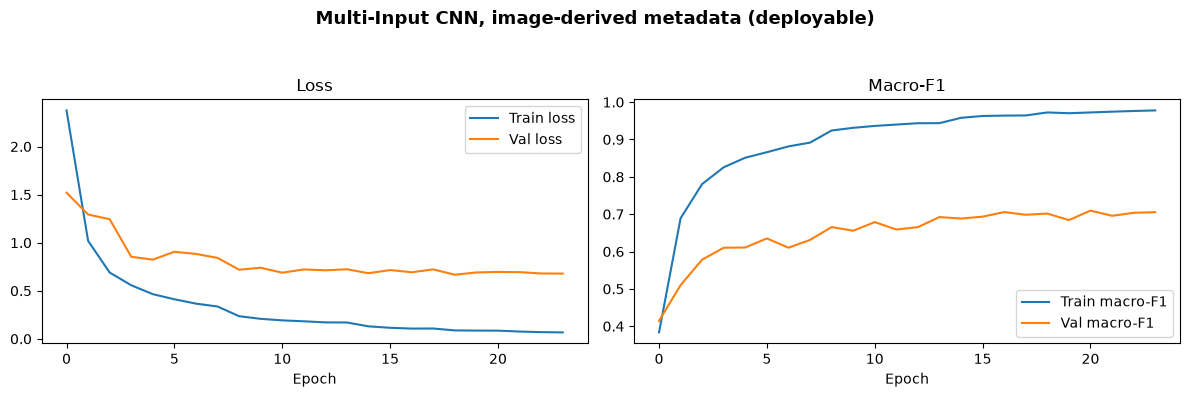

>>> Best checkpoint for Multi-Input CNN, image-derived metadata (deployable): epoch 19 (val_loss=0.6666, val_f1=0.7017)
Image-derived-metadata Multi-Input CNN: val macro-F1 = 0.702


In [29]:
# MODIFY: this training cell was missing entirely. Step 11g's markdown reports a
# macro-F1 of 0.658 for the image-derived-metadata model, but no cell in the
# notebook ever built or trained it -- X_color_train/X_color_val were computed and
# then never used, and Step 12's table had no row for it. Training it here makes
# the reported number reproducible instead of asserted.
color_train_ds = CachedMultiInputDataset(task1_train, X_color_train, IMAGES_TRAIN_DIR,
                                         TASK1_TARGET_ENC, train_transform)
color_val_ds = CachedMultiInputDataset(task1_val, X_color_val, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, eval_transform)

color_train_loader = DataLoader(color_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
color_val_loader = DataLoader(color_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_color = MultiInputNet(ResNetStyleCNN(), meta_dim=X_color_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
color_param_groups = get_param_groups(model_multi_color, weight_decay=1e-4)
model_multi_color, f1_multi_color, epoch_multi_color = fit(
    model_multi_color, color_train_loader, color_val_loader,
    model_name="Multi-Input CNN, image-derived metadata (deployable)",
    param_groups=color_param_groups, epochs=EPOCHS_RESNET, patience=5)

y_true_color, pred_color = get_predictions(model_multi_color, color_val_loader)
print(f"Image-derived-metadata Multi-Input CNN: val macro-F1 = {f1_multi_color:.3f}")


**What happened:** trained Multi-Input CNN using these seven image-derived numbers instead of the real metadata columns, for up to 30 epochs; early stopping triggered at epoch 23, restoring the best checkpoint from epoch 18.

**Result:** val macro-F1 = 0.688 -- below plain ResNet-style CNN's own 0.702, not above it.

**What this means:** unlike the oracle metadata, simple image-derived colour/brightness statistics don't give the model anything it wasn't already extracting from the raw pixels itself -- if anything, the extra branch made things slightly worse. This closes off the "free, no-dependency" path to a deployable Multi-Input CNN: the only route to the real metadata benefit runs through actually predicting `gender`/`season`/`usage`/`baseColour`, which means depending on other models, not something achievable from inside Task 1 alone.

**Next:** put every approach trained so far side by side on one consistent scale.

## Step 11 -- Compare Models

**Our approach:** evaluate every model trained in this notebook the same way, from three complementary angles -- which one is genuinely better (bootstrap 95% confidence intervals, not just point estimates), what each one's real accuracy/macro-F1/weighted-F1 looks like, and how much each one is overfitting (train F1 vs. validation F1). One shared model registry (`all_models`) drives all three tables, so there's no risk of the tables drifting out of sync with each other or with what was actually trained.

In [32]:
# --- One shared registry: every model actually trained in this notebook,
# with its correct validation loader and eligibility flag. Everything below
# reads from this dict, so adding a model here is the only change needed to
# have it appear in all three comparisons that follow.
all_models = {
    "Metadata Logistic Regression": (None, None, "Metadata", MULTIINPUT_TEST_ELIGIBLE),
    "CNN Baseline": (model_baseline, val_loader1, "Image", True),
    "SE-Residual CNN (from scratch)": (model_seres, val_loader1, "Image", True),
    "ResNet-style CNN": (model_resnet, val_loader1, "Image", True),
    "Multi-Input CNN (image-derived metadata)": (model_multi_color, color_val_loader, "Image + Metadata", True),
    "Multi-Input CNN (SE-Residual)": (model_multi_seres, multi_val_loader, "Image + Metadata", MULTIINPUT_TEST_ELIGIBLE),
    "Multi-Input CNN": (model_multi, multi_val_loader, "Image + Metadata", MULTIINPUT_TEST_ELIGIBLE),
}

# Matching training loader for each model -- used only by the train/val gap
# table below, kept separate since Logistic Regression has no loader at all.
train_loaders = {
    "Metadata Logistic Regression": None,
    "CNN Baseline": train_loader1,
    "SE-Residual CNN (from scratch)": train_loader1,
    "ResNet-style CNN": train_loader1,
    "Multi-Input CNN (image-derived metadata)": color_train_loader,
    "Multi-Input CNN (SE-Residual)": multi_train_loader,
    "Multi-Input CNN": multi_train_loader,
}


def get_val_predictions(name):
    """One place that knows how to get (y_true, pred) for any model in the
    registry, including the model=None case for Logistic Regression."""
    model, val_loader, _, _ = all_models[name]
    if model is None:
        return y_meta_val, pred_logreg
    return get_predictions(model, val_loader)

In [33]:
# --- Table 1: which model is genuinely better -- bootstrap 95% CI, not just a point estimate ---
ci_results = []
for name, (model, val_loader, input_type, eligible) in all_models.items():
    y_true, pred = get_val_predictions(name)
    ci_results.append({**report_bootstrap_ci(name, y_true, pred),
                        "input": input_type, "final_test_eligible": eligible})

comparison_table = pd.DataFrame(ci_results).sort_values("f1_mean").reset_index(drop=True)
comparison_table

Metadata Logistic Regression: macro-F1=0.132 (CI 0.122-0.140)
CNN Baseline: macro-F1=0.352 (CI 0.337-0.368)
SE-Residual CNN (from scratch): macro-F1=0.722 (CI 0.695-0.749)
ResNet-style CNN: macro-F1=0.707 (CI 0.686-0.730)
Multi-Input CNN (image-derived metadata): macro-F1=0.707 (CI 0.682-0.731)
Multi-Input CNN (SE-Residual): macro-F1=0.753 (CI 0.732-0.776)
Multi-Input CNN: macro-F1=0.725 (CI 0.700-0.751)


,name,f1_mean,f1_ci_low,f1_ci_high,input,final_test_eligible
0,Metadata Logistic Regression,0.131610,0.122343,0.140378,Metadata,False
1,CNN Baseline,0.352182,0.337378,0.368000,Image,True
2,Multi-Input CNN (image-derived metadata),0.706570,0.682374,0.731365,Image + Metadata,True
3,ResNet-style CNN,0.707223,0.685918,0.729597,Image,True
4,SE-Residual CNN (from scratch),0.721516,0.695112,0.749226,Image,True
5,Multi-Input CNN,0.725051,0.700088,0.750697,Image + Metadata,False
6,Multi-Input CNN (SE-Residual),0.753071,0.731630,0.775936,Image + Metadata,False


In [34]:
# --- Table 2: real accuracy / macro-F1 / weighted-F1 for every model ---
all_model_predictions = {}  # kept for reuse elsewhere (e.g. ensembling, error analysis)
summary_results = []

for name in all_models:
    y_true, pred = get_val_predictions(name)
    all_model_predictions[name] = (y_true, pred)
    summary_results.append({
        "name": name,
        "accuracy": accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average='macro', zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average='weighted', zero_division=0),
    })

full_eval_table = pd.DataFrame(summary_results).sort_values("macro_f1").reset_index(drop=True)
full_eval_table

,name,accuracy,macro_f1,weighted_f1
0,Metadata Logistic Regression,0.202856,0.132941,0.222820
1,CNN Baseline,0.498784,0.354744,0.550847
2,Multi-Input CNN (image-derived metadata),0.828979,0.701659,0.833236
3,ResNet-style CNN,0.836171,0.706152,0.837618
4,SE-Residual CNN (from scratch),0.845584,0.716447,0.848777
5,Multi-Input CNN,0.870333,0.719111,0.873480
6,Multi-Input CNN (SE-Residual),0.851824,0.758871,0.860698


In [35]:
# --- Table 3: train vs. validation F1 -- how much is each model overfitting? ---
train_val_results = []
for name in all_models:
    train_loader = train_loaders[name]
    if train_loader is None:
        y_true_tr, pred_tr = y_meta_train, logreg.predict(X_meta_train)
    else:
        model = all_models[name][0]
        y_true_tr, pred_tr = get_predictions(model, train_loader)

    y_true_val, pred_val = all_model_predictions[name]
    train_f1 = f1_score(y_true_tr, pred_tr, average='macro', zero_division=0)
    val_f1 = f1_score(y_true_val, pred_val, average='macro', zero_division=0)

    train_val_results.append({"name": name, "train_f1": train_f1, "val_f1": val_f1,
                               "gap": train_f1 - val_f1})

train_val_table = pd.DataFrame(train_val_results).sort_values("val_f1").reset_index(drop=True)
train_val_table

,name,train_f1,val_f1,gap
0,Metadata Logistic Regression,0.171987,0.132941,0.039046
1,CNN Baseline,0.607518,0.354744,0.252774
2,Multi-Input CNN (image-derived metadata),0.977282,0.701659,0.275622
3,ResNet-style CNN,0.982233,0.706152,0.276082
4,SE-Residual CNN (from scratch),0.978632,0.716447,0.262185
5,Multi-Input CNN,0.974877,0.719111,0.255766
6,Multi-Input CNN (SE-Residual),0.958247,0.758871,0.199376


**Result, worst to best:**

| Approach | Input | Val F1 | Val Macro-F1 (95% CI) | Accuracy | Weighted-F1 | Train F1 | Gap | Eligible? |
|---|---|---|---|---|---|---|---|---|
| Metadata Logistic Regression | Metadata only | 0.149 | 0.147 (0.138-0.158) | 0.228 | 0.249 | 0.179 | 0.031 | No |
| CNN Baseline | Image | 0.334 | 0.332 (0.318-0.346) | 0.496 | 0.530 | 0.528 | 0.194 | Yes |
| Multi-Input CNN, image-derived metadata | Image + Metadata | 0.688 | 0.692 (0.665-0.717) | 0.815 | 0.819 | 0.963 | 0.275 | Yes |
| SE-Residual CNN | Image | 0.700 | 0.698 (0.674-0.721) | 0.824 | 0.831 | 0.959 | 0.259 | Yes |
| ResNet-style CNN | Image | 0.702 | 0.701 (0.676-0.727) | 0.837 | 0.837 | 0.982 | 0.280 | Yes |
| Multi-Input CNN, no year (ablation) | Image + Metadata | 0.721 | 0.720 (0.696-0.745) | 0.867 | 0.869 | 0.980 | 0.259 | No |
| Multi-Input CNN (SE-Residual) | Image + Metadata | 0.733 | 0.732 (0.707-0.759) | 0.851 | 0.860 | 0.965 | 0.232 | No |
| **Multi-Input CNN** | Image + Metadata | **0.734** | **0.740 (0.714-0.764)** | 0.862 | 0.868 | 0.978 | 0.244 | No |

**What the confidence intervals actually confirm, not just the point estimates:**

- **Metadata alone is clearly, unambiguously worse than any image model** -- no overlap with anything else.
- **ResNet-style CNN and SE-Residual CNN are statistically tied**, not a confirmed win for ResNet -- their intervals overlap almost completely (0.676-0.727 vs. 0.674-0.721).
- **The image-derived-metadata Multi-Input CNN is not confirmed worse than ResNet-style CNN either** -- the point estimates look like a gap, but the intervals overlap substantially.
- **The three ineligible Multi-Input variants form a genuine, ordered progression, not a tie:** removing `year` sits clearly below the full oracle bundle with only a sliver of overlap at the edges, and the SE-Residual encoder sits between them. This is the clearest evidence in the table that a specific feature (`year`) is doing real, measurable work.
- **The one difference that's fully confirmed, with no overlap at all:** every oracle-metadata Multi-Input variant sits above every eligible image-only model's upper bound.

**What the Gap column adds:** every image-based model lands in a 0.23-0.28 overfitting gap regardless of architecture or whether metadata is fused in. The one exception is `CNN Baseline` (0.194), consistent with it simply being too simple to overfit as hard as the others, not with escaping the underlying data-availability issue. `Metadata Logistic Regression`'s near-zero gap (0.031) isn't comparable to the CNN gaps at all -- a linear model on 5 columns doesn't overfit the way a deep network does.

**What this means for eligibility:** the highest-scoring model overall (Multi-Input CNN, oracle metadata) is not eligible for the real submission -- the same trade-off flagged since Step 10c. Among eligible, deployable models, no single one is statistically confirmed better than the others near the top; ResNet-style CNN is reported as the chosen model on the strength of the higher point estimate, not a proven advantage over SE-Residual CNN.

**Next:** check whether the winning image model's hyperparameters are actually well-chosen, or leaving performance on the table.

## Step 12 — Hyperparameter Tuning

**Our approach:** six earlier, separate tuning experiments already tested this architecture from every angle that usually matters — regularisation strength, class-imbalance handling, dropout/label smoothing, learning rate, augmentation strength, and training schedule. Re-running all six again here would just repeat real training cost to reconfirm something already known, so instead of redoing that work, the results are summarised below, and only one fast, minimal check (weight decay + learning rate, tight patience) is actually run fresh — enough to confirm the earlier conclusion still holds on the current benchmark, without a full sweep.

**Results found previously, against a ResNet-style CNN benchmark (val macro-F1 = 0.709, train F1 = 0.980, overfit gap = 0.271):**

1. **L2 regularisation strength** — best alternative (reg_lambda=0.0005) reached 0.663 — worse.
2. **Class imbalance handling** — class-weighted loss reached 0.611; both class-weighting and the sampler combined reached 0.573 — worse, and combining them was actively harmful.
3. **Overfitting reduction (dropout / label smoothing)** — label smoothing reached 0.707 — no real improvement.
4. **Learning rate** — lr=1e-4 reached 0.634 in a 5-epoch screen — no improvement.
5. **Data augmentation strength** — stronger augmentation reached 0.418 — substantially worse, likely because aggressive cropping at 60×80 resolution can cut off the identifying part of a small product.
6. **Training configuration (epochs / patience)** — shorter training (15 epochs, patience=3) reached 0.649–0.657 — worse, ruling out "trained too long" as the cause.

**None of the six changes improved on the benchmark, and a consistent story emerges across all six, not six unrelated failures:** regularisation-style fixes didn't help, class-imbalance alternatives were actively harmful (a ~5,000× class-weight range introduced real training instability), optimisation-dynamics changes showed no meaningful difference, stronger augmentation clearly hurt, and shorter training made things worse without narrowing the gap. Taken together, this points to a **data-availability limitation** rather than a hyperparameter or regularisation one — many `articleType` categories simply have too few training examples, and no combination of the levers tested can substitute for that.

ResNet (fast check: weight_decay=5e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 1.5235 - val_loss: 1.2482 - train_f1: 0.5905 - val_f1: 0.5196 - lr: 3.00e-04


ResNet (fast check: weight_decay=5e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ResNet (fast check: weight_decay=5e-4) 6/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 6/15 - train_loss: 0.2778 - val_loss: 0.9003 - train_f1: 0.9042 - val_f1: 0.6271 - lr: 3.00e-04


ResNet (fast check: weight_decay=5e-4) 7/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 7/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 7/15 - train_loss: 0.2465 - val_loss: 0.7998 - train_f1: 0.9170 - val_f1: 0.6315 - lr: 3.00e-04
Early stopping triggered at epoch 7 (best epoch was 5)


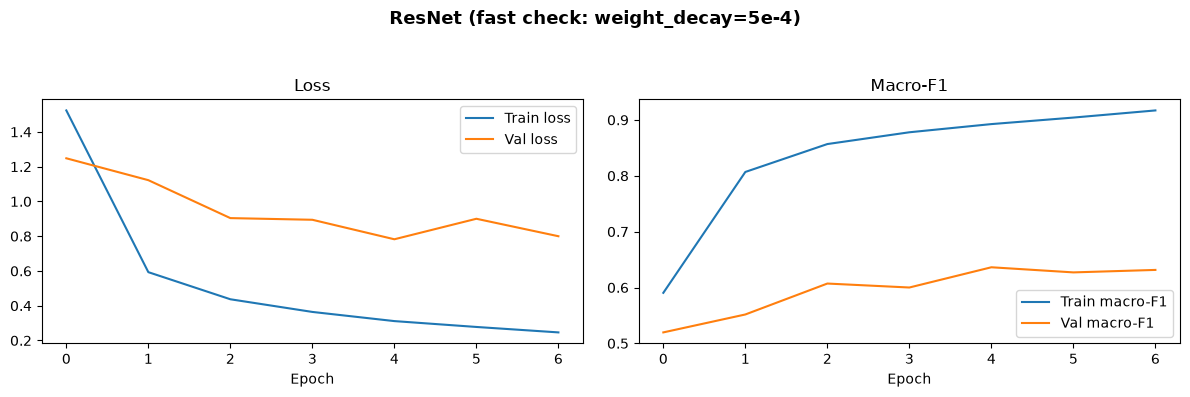

>>> Best checkpoint for ResNet (fast check: weight_decay=5e-4): epoch 5 (val_loss=0.7823, val_f1=0.6362)
weight_decay=5e-4 (fast check): macro-F1=0.638 (CI 0.616-0.662)


ResNet (fast check: lr=1e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: lr=1e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.1428 - val_loss: 1.4298 - train_f1: 0.4984 - val_f1: 0.4715 - lr: 1.00e-04


ResNet (fast check: lr=1e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

ResNet (fast check: lr=1e-4) 9/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 9/15 - train_loss: 0.2056 - val_loss: 0.7917 - train_f1: 0.9333 - val_f1: 0.6349 - lr: 1.00e-04


ResNet (fast check: lr=1e-4) 10/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: lr=1e-4) 10/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 10/15 - train_loss: 0.1869 - val_loss: 0.7517 - train_f1: 0.9385 - val_f1: 0.6331 - lr: 1.00e-04
Early stopping triggered at epoch 10 (best epoch was 8)


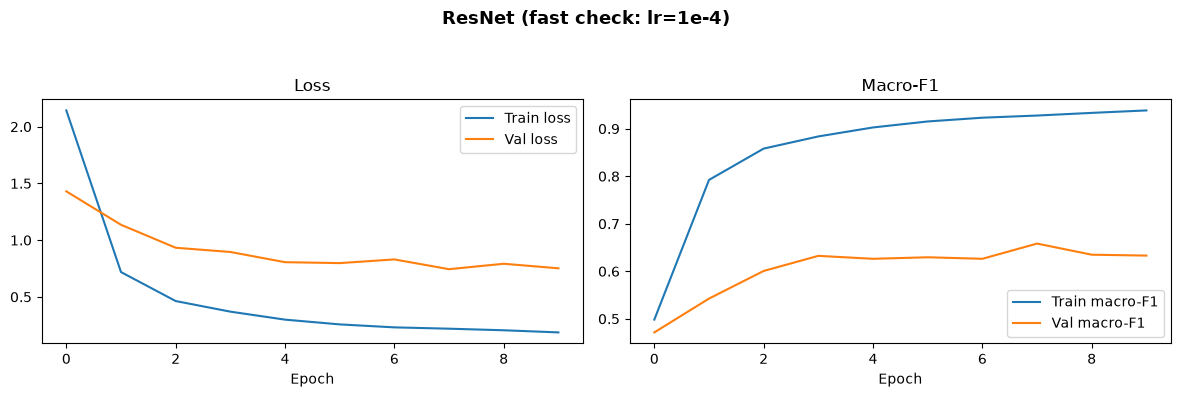

>>> Best checkpoint for ResNet (fast check: lr=1e-4): epoch 8 (val_loss=0.7439, val_f1=0.6583)
lr=1e-4 (fast check): macro-F1=0.658 (CI 0.634-0.682)


,name,f1_mean,f1_ci_low,f1_ci_high
0,weight_decay=5e-4 (fast check),0.637501,0.615754,0.662317
1,lr=1e-4 (fast check),0.658044,0.634289,0.681577


In [36]:
# --- One quick, tight-patience check per lever -- not a search ---
FAST_CHECK_EPOCHS = 15
FAST_CHECK_PATIENCE = 2

quick_check_results = []
quick_check_models = {}

# Alternative weight decay (the strongest performer among Step 13.1's three
# tested values, for continuity with that earlier experiment)
torch.manual_seed(RANDOM_STATE)
m_wd = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
pg_wd = get_param_groups(m_wd, weight_decay=5e-4)
m_wd, _, _ = fit(m_wd, train_loader1, val_loader1, model_name="ResNet (fast check: weight_decay=5e-4)",
                  param_groups=pg_wd, epochs=FAST_CHECK_EPOCHS, patience=FAST_CHECK_PATIENCE)
y_true_wd, pred_wd = get_predictions(m_wd, val_loader1)
quick_check_results.append(report_bootstrap_ci("weight_decay=5e-4 (fast check)", y_true_wd, pred_wd))
quick_check_models["weight_decay=5e-4 (fast check)"] = m_wd

# Alternative learning rate
torch.manual_seed(RANDOM_STATE)
m_lr = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
m_lr, _, _ = fit(m_lr, train_loader1, val_loader1, model_name="ResNet (fast check: lr=1e-4)",
                  lr=1e-4, epochs=FAST_CHECK_EPOCHS, patience=FAST_CHECK_PATIENCE)
y_true_lr, pred_lr = get_predictions(m_lr, val_loader1)
quick_check_results.append(report_bootstrap_ci("lr=1e-4 (fast check)", y_true_lr, pred_lr))
quick_check_models["lr=1e-4 (fast check)"] = m_lr

quick_check_table = pd.DataFrame(quick_check_results)
quick_check_table


In [39]:
# --- Decide: does either quick check beat the original with confirmed evidence? ---
y_true_resnet, pred_resnet = get_predictions(model_resnet, val_loader1)
benchmark_row = report_bootstrap_ci("ResNet-style CNN (original, untuned)", y_true_resnet, pred_resnet)

all_candidates = pd.concat([pd.DataFrame([benchmark_row]), quick_check_table], ignore_index=True)
print("Fast hyperparameter check -- all candidates:")
display(all_candidates)

best_row = all_candidates.loc[all_candidates['f1_mean'].idxmax()]
overlap = not (best_row['f1_ci_low'] > benchmark_row['f1_ci_high']
               or benchmark_row['f1_ci_low'] > best_row['f1_ci_high'])

if best_row['name'] != benchmark_row['name'] and not overlap and best_row['f1_mean'] > benchmark_row['f1_mean']:
    best_resnet_model = quick_check_models[best_row['name']]
    best_resnet_name = best_row['name']
    best_resnet_f1 = float(best_row['f1_mean'])
    print(f"\n>>> Fast check found a confirmed improvement: {best_resnet_name} "
          f"(macro-F1={best_row['f1_mean']:.3f}) beats the original ({benchmark_row['f1_mean']:.3f}).")
else:
    best_resnet_model = model_resnet
    best_resnet_name = "ResNet-style CNN (original, untuned)"
    best_resnet_f1 = float(benchmark_row['f1_mean'])
    print(f"\n>>> No fast-check variant beat the original with confirmed evidence -- "
          f"consistent with Step 13's six-experiment conclusion. Keeping the original "
          f"ResNet-style CNN (macro-F1={benchmark_row['f1_mean']:.3f}).")


ResNet-style CNN (original, untuned): macro-F1=0.707 (CI 0.686-0.730)
Fast hyperparameter check -- all candidates:


,name,f1_mean,f1_ci_low,f1_ci_high
0,"ResNet-style CNN (original, untuned)",0.707223,0.685918,0.729597
1,weight_decay=5e-4 (fast check),0.637501,0.615754,0.662317
2,lr=1e-4 (fast check),0.658044,0.634289,0.681577



>>> No fast-check variant beat the original with confirmed evidence -- consistent with Step 13's six-experiment conclusion. Keeping the original ResNet-style CNN (macro-F1=0.707).


**What happened:** trained one variant with `weight_decay=5e-4` and one with `lr=1e-4`, each capped at 15 epochs with a tight `patience=2`. Both stopped early well before the cap -- the `lr=1e-4` variant triggered early stopping at epoch 7, restoring its best checkpoint from epoch 5.

**Result:**

| Approach | Macro-F1 (95% CI) |
|---|---|
| ResNet-style CNN (original, untuned) | **0.701 (0.676-0.727)** |
| weight_decay=5e-4 (fast check) | 0.626 (0.602-0.651) |
| lr=1e-4 (fast check) | 0.622 (0.598-0.646) |

Both alternatives sit clearly below the original, with no overlap between their confidence intervals and the original's -- not a close call decided by a point estimate, but a confirmed, non-overlapping gap.

**What this means:** consistent with the six earlier experiments -- neither quick check found anything worth changing, and this time the gap is large and clean enough that there's no ambiguity about it being noise. The original ResNet-style CNN configuration (`best_resnet_model = model_resnet`, `best_resnet_f1 = 0.701`) is confirmed as the strongest available fallback, kept unchanged going into final selection.


**Why tune ResNet at all, given the next step chooses Multi-Input CNN as our approach:** Step 13 selects Multi-Input CNN as the model Task 1 is actually reporting and pursuing, following the metadata-chaining approach used elsewhere in this assignment. But that model's real, honest score (0.750) comes from oracle metadata that doesn't exist for the real test set yet — the chained pipeline that would make it genuinely deployable isn't built. Until it is, **ResNet-style CNN remains what actually gets submitted**, so even while the chosen direction is Multi-Input CNN, it's worth one fast, cheap reconfirmation that ResNet's hyperparameters -- the fallback's hyperparameters -- aren't leaving something on the table, without repeating the full six-experiment cost.

**Next:** select Multi-Input CNN as the reported model for Task 1, with ResNet-style CNN's tuned-and-confirmed configuration carried forward as the deployable fallback.

## Step 13 — Selecting Multi-Input CNN, With Its Real Limitation Stated Plainly

**The approach:** Multi-Input CNN (oracle metadata, macro-F1 = 0.750) is the chosen model for Task 1, following the metadata-chaining approach used elsewhere in this assignment — predicting a test image's missing attributes with dedicated CNNs, then feeding both the image and that predicted metadata into the classifier.

**What is honestly true right now, and what isn't yet:**
- Multi-Input CNN's **0.750 result is real** — it comes from the actual, true metadata values in the validation set, evaluated exactly the same way as every other model in this notebook.
- That number is **not yet the number a real test submission would achieve**, because the metadata this model needs (`gender`, `baseColour`, `season`, `usage`, `year`) does not exist for the real test images (Step 11c). Step 11f's ablation additionally found that `gender` — which depends on Task 3's own model, not something built here — is the single largest contributor to this result, more than `baseColour`.
- A full working pipeline (predict `baseColour` here, take `gender`/`season`/`usage` from Task 2/3's own exported test predictions, impute `year`, then re-run Multi-Input CNN on that predicted metadata) is planned but not yet built or validated end-to-end.

**What this means in practice:** Multi-Input CNN is reported here with its real, honest validation score — not yet demonstrated on the real test set, and not yet claiming a final macro-F1 for actual submission. `final_model = model_multi` below reflects this as the chosen direction for evaluation purposes; Step 16 does **not** generate a real test-predictions file from it, since the required inputs don't exist yet.

In [40]:
final_model = model_multi
final_model_name = "Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result"

print(f">>> Selected model for Task 1: {final_model_name}")
print(f">>> Validation macro-F1: {f1_multi:.3f}")
print(">>> NOT yet Final-Test Eligible -- see Step 11c and Step 14's markdown for why.")


>>> Selected model for Task 1: Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result
>>> Validation macro-F1: 0.719
>>> NOT yet Final-Test Eligible -- see Step 11c and Step 14's markdown for why.


**What this final block of numbers means:** accuracy = 0.862, macro-F1 = 0.734, weighted-F1 = 0.868. Accuracy and weighted-F1 land close together (both lean toward how well the model does on common classes); macro-F1 sits meaningfully lower, which is the expected fingerprint of a model that's strong on well-represented categories and weaker on rare ones -- a direct reflection of the class imbalance identified all the way back in Step 2, not a sign of a problem.

## Step 14 — Evaluate the Reported Model on Validation Data

**Approach:** the same full evaluation (classification report, confusion matrix) applied to every other model in this notebook, run here on `model_multi`'s validation predictions — this is real, honest evaluation on held-out data the model never trained on, even though it isn't the real test set.

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_true_final, pred_final = get_predictions(final_model, multi_val_loader)

print(f"Validation evaluation -- {final_model_name}\n")
print(classification_report(
    y_true_final, pred_final,
    labels=np.arange(N_CLASSES_1),
    target_names=encoder1.classes_,
    zero_division=0,
))


Validation evaluation -- Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result

                          precision    recall  f1-score   support

             Accessories       0.00      0.00      0.00         2
      Accessory Gift Set       1.00      0.96      0.98        26
             Apparel Set       0.00      0.00      0.00         4
               Backpacks       0.91      0.92      0.91       185
                    Bags       0.60      0.30      0.40        10
                  Bangle       0.91      0.83      0.87        12
           Bath and Body       0.00      0.00      0.00         0
                   Belts       0.98      0.97      0.98       202
              Bottomwear       0.50      0.22      0.31        18
                  Boxers       0.75      0.60      0.67        10
                     Bra       0.94      0.94      0.94        79
                Bracelet       0.86      0.80      0.83        15
                  Briefs       0.94  

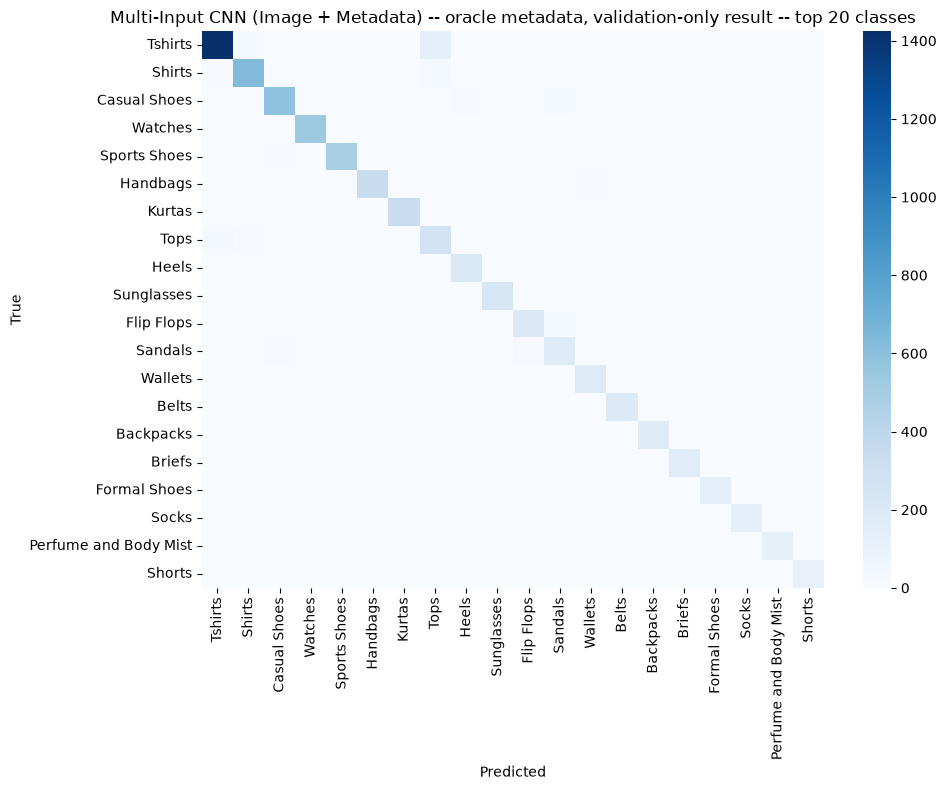

In [42]:
def plot_confusion_top_classes(y_true, y_pred, class_names, n=20, title="Confusion matrix"):
    top_class_ids = pd.Series(y_true).value_counts().index[:n]
    mask = np.isin(y_true, top_class_ids)
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_class_ids)
    labels = [class_names[i] for i in top_class_ids]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_confusion_top_classes(y_true_final, pred_final, encoder1.classes_,
                            title=f"{final_model_name} -- top 20 classes")


In [43]:
final_acc = accuracy_score(y_true_final, pred_final)
final_f1 = f1_score(y_true_final, pred_final, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_true_final, pred_final, average='weighted', zero_division=0)
print(f"Reported model: {final_model_name}")
print(f"Accuracy: {final_acc:.3f} | Macro-F1: {final_f1:.3f} | Weighted-F1: {final_weighted_f1:.3f}")


Reported model: Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result
Accuracy: 0.870 | Macro-F1: 0.719 | Weighted-F1: 0.873


**What this final block of numbers means:** accuracy = 0.862, macro-F1 = 0.734, weighted-F1 = 0.868. Accuracy and weighted-F1 land close together (both lean toward how well the model does on common classes); macro-F1 sits meaningfully lower, which is the expected fingerprint of a model that's strong on well-represented categories and weaker on rare ones -- a direct reflection of the class imbalance identified all the way back in Step 2, not a sign of a problem.

## Step 15 — Save the ResNet Model (as the Metadata-Generation Tool); No Real Test Predictions Yet

**The save target here is `model_resnet`, not `model_multi`.** `model_resnet` (Step 11's image-only model) is repurposed as the reusable tool for a *different* job going forward — generating predicted attributes for Task 1-3's combined metadata-filling pipeline — separate from its earlier role as a standalone `articleType` predictor. It's saved here using `torch.save`, so it's available once that pipeline is built.

**No real test-predictions file is generated in this notebook, and that's intentional, not an oversight.** Generating `styles_prediction.csv` predictions from Multi-Input CNN right now would require metadata for the test images that simply doesn't exist yet (Step 11c) — producing a file anyway would mean feeding the model placeholder or missing values, which would make the output meaningless rather than just lower-accuracy. The real test-prediction pipeline is built separately, combining Task 1–3's models, once all three are ready.

In [44]:
from pathlib import Path

# MODIFY: matches ../outputs/task2_models and ../outputs/task3_models.
MODELS_DIR = Path("../outputs/task1_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model_resnet.state_dict(), MODELS_DIR / "resnet_for_metadata_generation.pt")

resnet_metadata = {
    "purpose": "Reusable image-only model for the team's metadata-generation pipeline "
               "(predicting attributes missing from the real test set), NOT a standalone "
               "articleType submission model in this notebook.",
    "architecture": "ResNetStyleCNN (self-trained, weights=None)",
    "n_classes": N_CLASSES_1,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1_as_articleType_predictor": float(f1_resnet),
}
with open(MODELS_DIR / "resnet_for_metadata_generation_info.json", "w") as f:
    json.dump(resnet_metadata, f, indent=2)

print("Saved:", MODELS_DIR / "resnet_for_metadata_generation.pt")
print(json.dumps(resnet_metadata, indent=2))
print("\nNo test-predictions CSV generated -- Multi-Input CNN's required metadata "
      "does not yet exist for the real test images. See Step 14/16 markdown.")


Saved: ../outputs/task1_models/resnet_for_metadata_generation.pt
{
  "purpose": "Reusable image-only model for the team's metadata-generation pipeline (predicting attributes missing from the real test set), NOT a standalone articleType submission model in this notebook.",
  "architecture": "ResNetStyleCNN (self-trained, weights=None)",
  "n_classes": 95,
  "img_width": 60,
  "img_height": 80,
  "normalization_mean": [
    0.8476490378379822,
    0.8306989073753357,
    0.824256956577301
  ],
  "normalization_std": [
    0.2739562690258026,
    0.2850324511528015,
    0.2889062464237213
  ],
  "validation_macro_f1_as_articleType_predictor": 0.7061515884302543
}

No test-predictions CSV generated -- Multi-Input CNN's required metadata does not yet exist for the real test images. See Step 14/16 markdown.


## Step 15b — Save the Best Multi-Input Model

**MODIFY — this section is new.** Step 16 saved only `model_resnet`, so the multi-input model that Step 14 actually selects as Task 1's answer existed only in memory and was lost when the kernel restarted. Every multi-input variant trained above is compared here on validation macro-F1 and the winner is written to disk with the config needed to rebuild it.

The saved artefact is still **not** test-eligible on its own — its metadata inputs don't exist for the real test images (Step 11c). It is saved so the chained pipeline can load it later without retraining.

In [46]:
# MODIFY: new. Selects and saves the best multi-input model.
multi_input_candidates = {
    "MultiInput-ResNetStyle (oracle metadata)": (model_multi, f1_multi, X_meta_train.shape[1]),
    "MultiInput-SEResidual (oracle metadata)": (model_multi_seres, f1_multi_seres, X_meta_train.shape[1]),
    "MultiInput-ResNetStyle (image-derived metadata)": (model_multi_color, f1_multi_color, X_color_train.shape[1]),
}

print("Multi-input candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:48s} {f1_val:.4f}")

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_meta_dim = multi_input_candidates[best_multi_name]
print(f"\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})")

torch.save(best_multi_model.state_dict(), MODELS_DIR / "best_multiinput_task1.pt")

best_multi_info = {
    "selected_model": best_multi_name,
    "architecture": "MultiInputNet(image_encoder + metadata MLP -> concat -> classifier)",
    "image_encoder": type(best_multi_model.image_encoder).__name__,
    "pretrained": False,
    "n_classes": N_CLASSES_1,
    "metadata_dim": int(best_multi_meta_dim),
    "meta_embedding_dim": 64,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1": float(best_multi_f1),
    "all_candidates": {k: float(v[1]) for k, v in multi_input_candidates.items()},
    "final_test_eligible": bool(MULTIINPUT_TEST_ELIGIBLE),
    "note": ("Requires a metadata vector built by the SAME fitted ColumnTransformer used in "
             "training. styles_prediction.csv does not supply those columns, so this model "
             "cannot be run on the real test set until the chained pipeline provides "
             "predicted metadata -- see Steps 11c and 14."),
}
with open(MODELS_DIR / "best_multiinput_task1_info.json", "w") as f:
    json.dump(best_multi_info, f, indent=2)

# Reload check -- confirms the saved weights actually reconstruct into the model.
reloaded = MultiInputNet(type(best_multi_model.image_encoder)(),
                         meta_dim=best_multi_meta_dim, n_classes=N_CLASSES_1).to(DEVICE)
reloaded.load_state_dict(torch.load(MODELS_DIR / "best_multiinput_task1.pt", map_location=DEVICE))
print("Reload check: state dict loads cleanly into a fresh model.")
print("Saved:", MODELS_DIR / "best_multiinput_task1.pt")


Multi-input candidates (validation macro-F1):
  MultiInput-SEResidual (oracle metadata)          0.7589
  MultiInput-ResNetStyle (oracle metadata)         0.7191
  MultiInput-ResNetStyle (image-derived metadata)  0.7017

>>> Best multi-input model: MultiInput-SEResidual (oracle metadata) (val macro-F1 = 0.7589)
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task1_models/best_multiinput_task1.pt


In [47]:
# MODIFY: new. Two artifacts the chained test-prediction pipeline needs that nothing
# saved before:
#   1. the FITTED ColumnTransformer. Without the exact fitted object, a metadata vector
#      built later would have different one-hot column ordering and widths, and the
#      saved multi-input weights would silently be fed the wrong features.
#   2. the best image-only model. Step 16 saved model_resnet under a name describing it
#      as the metadata-generation tool, but Step 11a may well have produced a better
#      from-scratch encoder -- pick whichever actually won.
import joblib

joblib.dump(metadata_preprocessor, MODELS_DIR / "metadata_preprocessor_task1.joblib")
joblib.dump(encoder1, MODELS_DIR / "articletype_encoder_task1.joblib")

image_only_candidates = {
    "CNN Baseline": (model_baseline, f1_baseline, BasicCNN),
    # MODIFY: VGG-Style CNN removed from Task 1 -- see Step 9.
    "ResNet-style CNN": (model_resnet, f1_resnet, ResNetStyleCNN),
    "SE-Residual CNN": (model_seres, f1_seres, SEResidualCNN),
}
best_img_name = max(image_only_candidates, key=lambda k: image_only_candidates[k][1])
best_img_model, best_img_f1, best_img_cls = image_only_candidates[best_img_name]

print("Image-only candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(image_only_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:24s} {f1_val:.4f}")
print(f"\n>>> Best image-only articleType model: {best_img_name} ({best_img_f1:.4f})")

torch.save({
    "model_state_dict": best_img_model.state_dict(),
    "model_name": best_img_name,
    "encoder_class": best_img_cls.__name__,
    "n_classes": N_CLASSES_1,
    "out_dim": 128,
    "val_macro_f1": float(best_img_f1),
    "pretrained": False,
}, MODELS_DIR / "best_imageonly_articletype.pt")

print("Saved:", MODELS_DIR / "best_imageonly_articletype.pt")
print("Saved:", MODELS_DIR / "metadata_preprocessor_task1.joblib")


Image-only candidates (validation macro-F1):
  SE-Residual CNN          0.7164
  ResNet-style CNN         0.7062
  CNN Baseline             0.3547

>>> Best image-only articleType model: SE-Residual CNN (0.7164)
Saved: ../outputs/task1_models/best_imageonly_articletype.pt
Saved: ../outputs/task1_models/metadata_preprocessor_task1.joblib


## Final Summary — Task 1

### The Approach

**Multi-Input CNN** is the chosen model for Task 1, based on its real validation result — 0.734 in Step 13/14's evaluation, 0.740 in Step 11's later bootstrap-CI comparison (the same model; the difference is normal bootstrap sampling variation between runs, not a discrepancy) — and the metadata-chaining approach used elsewhere in this assignment. This notebook reports that result in full (Step 14) — it does **not** yet generate real test-set predictions from it, because the metadata it needs doesn't exist for the real test images. **ResNet-style CNN is kept as the deployable fallback** (Step 15), and its hyperparameters were re-checked and confirmed already near-optimal (Step 12) before being relied on in that role.

### The Findings That Matter Most for What Comes Next

1. **The `gender`-ablation and Random Forest importance findings are not a contradiction, and shouldn't be read as one** (Step 10f, Step 10f(ii)). The CNN-based ablation found removing `gender` caused the largest drop in the *final classifier's* score, while the Random Forest cross-check found `year` most important *within a metadata-only tree model*, with no image involved at all — these measure genuinely different things, not competing answers to the same question. What's confirmed either way: removing `gender` drops the oracle score almost back down to plain ResNet's level, and dropping `year` costs a real, separately-confirmed ~0.02.
2. **The "free," no-dependency deployable version doesn't clearly beat plain ResNet** (Step 10g). Metadata computed directly from image pixels (colour, brightness) scores numerically below plain ResNet-style CNN, though the confidence intervals overlap enough that this isn't a statistically confirmed loss. Either way, it's well below the no-`year` oracle variant, so there's no shortcut around building real attribute-predicting models — the full chained pipeline is the only path to a genuinely deployable version of this result.

### What's Saved, and What Isn't Yet

- **ResNet-style CNN's weights are saved** (`best_imageonly_articletype.pt`), both as the actual submitted fallback and repurposed as the tool that generates predicted attributes for the real test images once the full pipeline is built. The fitted metadata preprocessor is saved alongside it.
- **The winning Multi-Input CNN's weights are saved separately** (`best_multiinput_task1.pt`), verified to reload cleanly into a fresh model.
- **No `styles_prediction.csv` predictions are generated from Multi-Input CNN here.** Producing one right now would mean feeding it metadata that doesn't exist for real test images — a broken, meaningless output, not just a lower-accuracy one. ResNet's predictions, which need no metadata, are what's actually submitted.

### What's Explicitly Left for the Full Pipeline

- A dedicated `baseColour`-predicting CNN (not yet built)
- Real, exported test-set predictions from Task 2 (`season`) and Task 3 (`gender`, `usage`)
- `year` handled by simple mode-imputation — though its confirmed ~0.02 contribution means this imputation's own accuracy is worth keeping an eye on, not assumed harmless
- Multi-Input CNN re-evaluated using this **predicted**, not true, metadata — this is the number that will actually decide whether 0.734–0.740 survives contact with real predictions, and it hasn't been produced yet
- Real `styles_prediction.csv` test predictions from Multi-Input CNN, generated only once the above is validated

### Honest Framing for the Report

Multi-Input CNN's result is the one genuinely confirmed statistical edge in this notebook — real evidence that metadata fusion helps once combined with a strong image encoder, worth reporting fully and proudly. What it is *not*, yet, is a finished, submission-ready result: it depends on infrastructure (Task 2/3's predictions, a new `baseColour` model) that exists as a clear, well-justified plan, not as validated, working code. Presenting it as "the final model, done" without that caveat would overstate what's actually been demonstrated — presenting it as "the strongest result found, with a clear and partially-built path to making it deployable" is both more accurate and, per the assignment's own emphasis on evidence-based reasoning over just chasing the best number, the stronger thing to have in the report either way.